# 16. Unequal Noise, Unequal Errors

**The question.** Notebook 04 measured that noise exposure is group-correlated in real
person records: name-change rates differ by NCSBE sex and race codes, with fitted
multipliers spanning a factor of ~6 between the sexes on the family-name channel. A
linkage system run on such records makes its errors unequally too — and it can be unequal
on **two different sides**: missed matches (a group's records fail to link) and false
matches (a group's records get merged into the wrong person). FAIR-01 asks whether the
embedding system is net-positive on **both** sides, for **every** group, at **matched**
operating points — or whether it buys its aggregate win by moving error mass onto the
high-exposure group.

**What this notebook settles (and what it deliberately does not claim).** PLAN §9 scopes
fairness as *measurement with robustness bands, deliberately not the headline*. This
notebook builds and demonstrates the full FAIR-01 instrument: group-correlated
re-corruption from the measured exposure model, per-group both-sides error rates with
entity-BCa CIs at fixed-precision operating points, paired shared-draw system deltas per
group, an exposure-vs-mechanism decomposition, demographic-label-error robustness bands,
and per-group unresolvable-rate accounting — registered as `fair01_disparity_panel`.

**The critical design fact, stated before anything runs.** The calibrated corpus was
generated with UNIFORM exposure — `historical_50k` has no race/ethnicity at all and its
sex field is error-injected free text, so notebook 05 could not key the NCSBE-coded NB04
exposure model on it (its registered meta says exactly this and delegates the group-keyed
application to THIS notebook). The honest smoke path, which NB05 pre-declared: assign
**synthetic group labels** to the corpus's eval-half entities by sampling from the
REGISTERED group frequencies in `nse01_exposure_model` (real NC aggregates — group codes,
counts, multipliers; no raw records), then re-corrupt the eval slice so per-group channel
rates track the measured multipliers. Every figure and table below therefore carries the
same loud label: **group membership is SIMULATED (drawn from real measured frequencies);
the exposure differentials are the REAL measured NC multipliers — mechanism calibrated,
membership simulated.** The definitive run with real record-level group labels is the
`# [RUN-IN-TARGET node]` placard near the end. Because membership is assigned to entities
at random, group labels are uncorrelated with name content — so the *mechanism* channel of
the decomposition in §7 is empty by construction, and that section doubles as an
instrument validation (details there).

**Masking note.** No NC record-level value enters this notebook: the corpus is
`historical_50k`-derived (public historical records), and the only NC content is
registered aggregates (group frequencies, fitted multipliers, channel rates) — so there
is nothing to mask (DATA_GOVERNANCE.md: aggregates only).

In [1]:
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import ndtr, ndtri

from er_lab.blocking import ann, matchkeys
from er_lab.cluster.schemes import transitive_closure
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.eval.bootstrap import bootstrap_ci
from er_lab.eval.identifiability import unresolvable_report
from er_lab.eval.metrics import blocking_metrics
from er_lab.eval.operating_points import find_threshold_for_precision
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.models.encoders import build_encoder
from er_lab.noise.channels import (
    PerRecordChannel,
    field_dropout,
    get_cell,
    hub_value,
    load_lexicon,
    name_order_swap,
    nickname,
    typo,
)
from er_lab.noise.exposure import ExposureModel
from er_lab.noise.generate import generate_corpus
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box
from er_lab.serialize import serialize_frame
from er_lab.train.loop import train_encoder

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()
SECTION_TIMES: list[tuple[str, float]] = []


def tick(label: str, t0: float) -> None:
    """Record and print one section's wall-clock — the smoke budget is measured, not vibes."""
    secs = time.time() - t0
    SECTION_TIMES.append((label, secs))
    print(f"[section timing] {label}: {secs:.0f}s")

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

Encoder shape and step budget are the same tier table as notebooks 09/12/13/14, so the
NB12 recipe transfers verbatim (asserted against the registry below, not assumed).
Protocol constants — the precision targets, the exposure dose, the flip rates, the
group-scoring floor rule — are pre-registered in the FAIR-01 card and identical in *kind*
at every tier (the floor's numeric value scales with tier and is printed here, before the
card, as part of the pre-registration). Analysis budgets (grids, bootstrap replicates,
flip replicates) scale with tier. Smoke budget for the whole notebook: **<= ~30 min
uncontended on the 4-CPU container** (two sibling notebook builds share these CPUs today;
2-4x wall-clock inflation is expected and not chased).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 3_000, "mid": None, "target": None, "analytical": 3_000}  # train records
STEPS_BY_TIER = {"smoke": 250, "mid": 2000, "target": 4000, "analytical": 250}
MODEL_SHAPE = {
    "smoke": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
    "mid": {"dim": 256, "layers": 4, "heads": 4, "max_len": 192},
    "target": {"dim": 384, "layers": 6, "heads": 6, "max_len": 192},
    "analytical": {"dim": 128, "layers": 2, "heads": 4, "max_len": 128},
}[TIER]
STEPS = STEPS_BY_TIER[TIER]
ENC_BATCH = 256  # inference encode batch
K_CAND = 10  # dense candidate budget (bas02's noise-slice k, matched to NB13/14, not tuned)
GRID = {"smoke": 60, "mid": 150, "target": 200, "analytical": 60}[TIER]
N_BOOT = {"smoke": 500, "mid": 1000, "target": 2000, "analytical": 500}[TIER]
N_FLIP = {"smoke": 12, "mid": 30, "target": 50, "analytical": 12}[TIER]  # per flip rate
N_VALID = 20_000  # FS stand-in validation pairs vs bas01_scored_pairs (NB14's rail)
# protocol constants (PLAN §5 + the FAIR-01 card below — never tuned on outcomes):
PREC_TARGETS = (0.99, 0.995)  # fixed B-cubed entity-precision operating points
PREC_PRIMARY = 0.99  # every delta / band / decomposition is priced here (card)
PPRIM = f"precision@{PREC_PRIMARY}"
GROUP_DOSE = 0.30  # total per-duplicate dose over the 3 name-change-bearing channels
#                    (BEYOND-AUDITED scaling, labeled — NB14's regime-map convention)
FLIP_RATES = (0.01, 0.05, 0.10)  # demographic-label-error rates (PLAN §3 FAIR-01 row)
MIN_GROUP_ENT = {"smoke": 100, "mid": 300, "target": 1000, "analytical": 100}[TIER]
OPS_STRATA_MAX = 3  # entity ops-count strata 0 / 1 / 2 / 3+ for the §7 decomposition
PRIMARY_SEED = int(cfg.run.seed)
REGEN_SEED = PRIMARY_SEED + 501  # one re-corruption seed (dup skeleton + channels)

cfg.model.kind = "scratch_char"
cfg.model.dim = MODEL_SHAPE["dim"]
cfg.model.layers = MODEL_SHAPE["layers"]
cfg.model.heads = MODEL_SHAPE["heads"]
cfg.model.max_len = MODEL_SHAPE["max_len"]
cfg.train.steps = STEPS
BATCH = int(cfg.train.batch_size)
print(f"tier={TIER}: encoder {MODEL_SHAPE}, steps={STEPS}, batch={BATCH}, train-slice "
      f"budget {SIZES[TIER]}; k={K_CAND}; grid {GRID}, n_boot {N_BOOT}, "
      f"{N_FLIP} flip replicates per rate {FLIP_RATES}")
print(f"protocol: precision {PREC_TARGETS} (primary {PREC_PRIMARY}); group dose "
      f"{GROUP_DOSE}/duplicate over the name-change-bearing channels (BEYOND-AUDITED, "
      f"labeled); group-scoring floor >= {MIN_GROUP_ENT} eval entities at this tier; "
      "cost-grid operating points are inherited from bas01/clu01 and not re-swept here "
      "(budget; NB17 re-unites them).")

tier=smoke: encoder {'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}, steps=250, batch=64, train-slice budget 3000; k=10; grid 60, n_boot 500, 12 flip replicates per rate (0.01, 0.05, 0.1)
protocol: precision (0.99, 0.995) (primary 0.99); group dose 0.3/duplicate over the name-change-bearing channels (BEYOND-AUDITED, labeled); group-scoring floor >= 100 eval entities at this tier; cost-grid operating points are inherited from bas01/clu01 and not re-swept here (budget; NB17 re-unites them).


## 1. The arena: everything loads through the registry

The DAG-declared upstreams (`calibrated_corpus`, `nse01_exposure_model`,
`cal01_calibration_map`) plus what the derivation needs: `met07_splits` (eval
discipline), `bas02_blocking_frontier` (the NB12 encoder recipe), `bas01_scored_pairs`
(validates the FS stand-in, NB14's rail), `met04_power_table` (BOTH detectability bars),
and `hyb01_rule_value_map` (which rule earned its place — the hybrid arm here includes
exactly the rules that did).

`TEXT_ROLES` inherits notebook 08's **measured decision**: `full_name` is EXCLUDED — it
roughly doubles serialized length (forcing truncation at the smoke byte window) and NB05
leaves it stale under nickname/typo edits, so keeping it would leak the clean name past
the injected noise.

In [4]:
t_sec = time.time()
corpus, corpus_meta = registry.load("calibrated_corpus", tier=cfg.run.tier)
exposure_tbl, exposure_meta = registry.load("nse01_exposure_model", tier=cfg.run.tier)
cal01, cal01_meta = registry.load("cal01_calibration_map", tier=cfg.run.tier)
splits, _splits_meta = registry.load("met07_splits", tier=cfg.run.tier)
bas02, bas02_meta = registry.load("bas02_blocking_frontier", tier=cfg.run.tier)
bas01_pairs, _bas01_pairs_meta = registry.load("bas01_scored_pairs", tier=cfg.run.tier)
met04, met04_meta = registry.load("met04_power_table", tier=cfg.run.tier)
hyb01, hyb01_meta = registry.load("hyb01_rule_value_map", tier=cfg.run.tier)

CORPUS_PROVENANCE = (
    f"calibrated_corpus run {corpus_meta['created_at']} (cfg {corpus_meta['config_hash']}, "
    f"tier {corpus_meta['tier']}, seed {corpus_meta['extra']['seed']})"
)
RECIPE = dict(bas02_meta["extra"]["encoder_recipe"])
print(f"corpus: {CORPUS_PROVENANCE}")
print(f"  {len(corpus):,} records / {corpus['entity_id'].nunique():,} entities")
print(f"recipe source: bas02_blocking_frontier run {bas02_meta['created_at']} "
      f"(tier {bas02_meta['tier']}): loss={RECIPE['loss']}, regime={RECIPE['regime']}, "
      f"miner={RECIPE['miner']}, augment={RECIPE['augment']}, steps={RECIPE['steps']} x "
      f"batch {RECIPE['batch']}, model={RECIPE['model']}")
if str(bas02_meta["tier"]) == TIER:
    assert int(RECIPE["steps"]) == STEPS and int(RECIPE["batch"]) == BATCH, (
        f"recipe budget {RECIPE['steps']}x{RECIPE['batch']} != tier table {STEPS}x{BATCH}"
    )
    assert dict(RECIPE["model"]) == MODEL_SHAPE, (
        f"recipe shape {RECIPE['model']} != tier table {MODEL_SHAPE}"
    )

# NB05's delegation, quoted from the registered meta — the design fact this notebook rests on.
print("\nNB05's registered exposure statement (calibrated_corpus meta, verbatim):")
print("  " + str(corpus_meta["extra"]["exposure"]))

corpus: calibrated_corpus run 2026-08-26T02:41:13.372218+00:00 (cfg 129c9d9243ca, tier smoke, seed 17)
  32,259 records / 2,507 entities
recipe source: bas02_blocking_frontier run 2026-08-28T19:04:32.479620+00:00 (tier smoke): loss=infonce, regime=scratch_char, miner=inbatch, augment=none, steps=250 x batch 64, model={'dim': 128, 'layers': 2, 'heads': 4, 'max_len': 128}

NB05's registered exposure statement (calibrated_corpus meta, verbatim):
  uniform (no exposure model): historical_50k lacks race/ethnicity entirely and codes sex as free-text Wikidata gender (itself error-injected), so the NCSBE-coded NB04 exposure model cannot key on it without inventing a code mapping; the wiring is demonstrated on an NC-derived synthetic block instead (nse02_exposure_demo), and FAIR-01 (NB16) applies the model where group columns exist


In [5]:
# NB08's measured field-set decision, inherited (see the section note above).
TEXT_ROLES = ["given_name", "family_name", "dob", "city", "zip", "sex"]
assert TEXT_ROLES == list(RECIPE["text_roles"]), (
    f"TEXT_ROLES {TEXT_ROLES} != the registered recipe's {RECIPE['text_roles']}"
)
KEEP_COLS = ["record_id", "entity_id"] + TEXT_ROLES
print(f"TEXT_ROLES (full_name excluded, NB08 decision) = {TEXT_ROLES}")
print("group labels live in SEPARATE columns (grp_sex / grp_race) that are never "
      "serialized: every system below is structurally blind to group membership — any "
      "disparity can only arrive through the noise itself.")

SCHEME = "entity_disjoint"
train_ids = set(splits["schemes"][SCHEME]["train"])
eval_ids = set(splits["schemes"][SCHEME]["eval"])
straddle = splits["metadata"]["checks"][SCHEME]["entities_straddling"]
assert straddle == 0, "entity-disjoint split must have zero straddling entities (PLAN §5)"
train_full = corpus[corpus["record_id"].isin(train_ids)].reset_index(drop=True)
eval_full = corpus[corpus["record_id"].isin(eval_ids)].reset_index(drop=True)
print(f"split {SCHEME}: {len(train_full):,} train / {len(eval_full):,} eval records "
      f"({train_full['entity_id'].nunique():,} / {eval_full['entity_id'].nunique():,} "
      "entities, 0 straddling). The encoder sees the train half only; the eval half is "
      "re-corrupted below and every operating point / CI lives there.")

SER_SCHEME, SER_MISSING = str(cfg.serialize.scheme), str(cfg.serialize.missing)
assert {"scheme": SER_SCHEME, "missing": SER_MISSING} == dict(RECIPE["serialization"]), (
    "serialization drifted from the registered recipe"
)

TEXT_ROLES (full_name excluded, NB08 decision) = ['given_name', 'family_name', 'dob', 'city', 'zip', 'sex']
group labels live in SEPARATE columns (grp_sex / grp_race) that are never serialized: every system below is structurally blind to group membership — any disparity can only arrive through the noise itself.
split entity_disjoint: 16,164 train / 16,095 eval records (1,252 / 1,255 entities, 0 straddling). The encoder sees the train half only; the eval half is re-corrupted below and every operating point / CI lives there.


In [6]:
# BOTH MET-04 bars, from the registered meta (the binding convention: any single-seed
# ranking discussion quotes both) — plus the hyb01 ledger that fixes the hybrid arm.
SD_REPLICATE = float(met04_meta["extra"]["sd_replicate"])
BAR_SINGLE = float(met04_meta["extra"]["detect_bar_single_seed"])
BAR_RESID = float(met04_meta["extra"]["detect_bar_residual_inclusive"])
print(f"MET-04 bars (B3F1 units, registered meta): detect_bar_single_seed = "
      f"{BAR_SINGLE:.4f}, detect_bar_residual_inclusive = {BAR_RESID:.4f} "
      f"(sd_replicate {SD_REPLICATE:.4f}). Both bars are quoted with every single-seed "
      "conclusion below; deltas inside the residual-inclusive bar are within replicate "
      "noise across retrains even when a paired CI excludes zero. The bars are B3F1 "
      "units; here they are applied to B3-decomposed rate deltas as the stated "
      "order-of-magnitude caution lens (same metric family, same 0..1 scale).")

_hd = hyb01[hyb01["row_type"] == "delta"].set_index("system")
OV_DELTA = float(_hd.loc["emb+override", "delta_f1"])
OV_STABLE = bool(_hd.loc["emb+override", "sign_stable"])
GD_DELTA = float(_hd.loc["emb+guard", "delta_f1"])
GD_STABLE = bool(_hd.loc["emb+guard", "sign_stable"])
OV_REDUNDANCY = float(hyb01_meta["extra"]["grammar"]["override_redundancy_share"])
print(f"\nhyb01 ledger read (which rules earned their place, tier {hyb01_meta['tier']}):")
print(f"  exact-key override: paired dB3F1 {OV_DELTA:+.4f} vs embedding-only, "
      f"sign_stable={OV_STABLE} -> INCLUDED in the hybrid arm below")
print(f"  dob-year guard:     paired dB3F1 {GD_DELTA:+.4f}, sign_stable={GD_STABLE} -> "
      "EXCLUDED (it measurably HURT: 28.7% of its fires were true pairs on this corpus's "
      "native dob noise — HYB-01's refutation finding; rules earn their place "
      "individually, not as a class)")
assert OV_STABLE and OV_DELTA > 0, "hybrid arm contract: include only sign-stable-positive rules"
assert GD_STABLE and GD_DELTA < 0, "hybrid arm contract: the guard was sign-stable negative"

MET-04 bars (B3F1 units, registered meta): detect_bar_single_seed = 0.0862, detect_bar_residual_inclusive = 0.0865 (sd_replicate 0.0305). Both bars are quoted with every single-seed conclusion below; deltas inside the residual-inclusive bar are within replicate noise across retrains even when a paired CI excludes zero. The bars are B3F1 units; here they are applied to B3-decomposed rate deltas as the stated order-of-magnitude caution lens (same metric family, same 0..1 scale).

hyb01 ledger read (which rules earned their place, tier smoke):
  exact-key override: paired dB3F1 +0.0247 vs embedding-only, sign_stable=True -> INCLUDED in the hybrid arm below
  dob-year guard:     paired dB3F1 -0.0190, sign_stable=True -> EXCLUDED (it measurably HURT: 28.7% of its fires were true pairs on this corpus's native dob noise — HYB-01's refutation finding; rules earn their place individually, not as a class)


In [7]:
# The measured exposure model — the real NC aggregates everything below is keyed on — and
# NB04's binding small-group rules for this consumer, restated before use.
print("nse01_exposure_model (real NC aggregates; scope "
      f"{exposure_meta['extra']['scope']}, {exposure_meta['extra']['pairs_audited']:,} "
      "audited pairs):")
display(exposure_tbl[["channel", "group_col", "group", "n", "rate", "multiplier",
                      "mult_ci_low", "mult_ci_high"]])
print("NB04's binding rules for THIS notebook (from its registered small-print): "
      "(1) point multipliers may be used to CONSTRUCT group-correlated noise; (2) a "
      "county-subset multiplier may be cited as a measured disparity ONLY where its CI "
      "excludes 1; (3) the definitive multipliers are the statewide target-tier rerun.")
_fam_sex = exposure_tbl[(exposure_tbl["channel"] == "family_name_change")
                        & (exposure_tbl["group_col"] == "sex")].set_index("group")
print(f"the audit's headline, quoted: family_name_change by sex — F multiplier "
      f"{_fam_sex.loc['F', 'multiplier']:.2f} [{_fam_sex.loc['F', 'mult_ci_low']:.2f}, "
      f"{_fam_sex.loc['F', 'mult_ci_high']:.2f}] vs M {_fam_sex.loc['M', 'multiplier']:.2f} "
      f"[{_fam_sex.loc['M', 'mult_ci_low']:.2f}, {_fam_sex.loc['M', 'mult_ci_high']:.2f}] "
      "— both CIs exclude 1; this is the exposure contrast the smoke demonstration runs on.")
tick("§1 arena + upstreams + bars", t_sec)

nse01_exposure_model (real NC aggregates; scope county_subset_subsample, 120,000 audited pairs):


,channel,group_col,group,n,rate,multiplier,mult_ci_low,mult_ci_high
0,family_name_change,race,W,92443,0.001082,0.854011,0.702291,1.038466
1,family_name_change,race,B,13588,0.001398,1.103915,0.706888,1.723447
2,family_name_change,race,U,6107,0.003111,2.456198,1.573197,3.832398
3,family_name_change,race,O,3292,0.003341,2.637974,1.473833,4.716134
4,family_name_change,race,A,3231,0.000619,0.488687,0.134029,1.779705
5,family_name_change,race,M,1064,0.000940,0.741987,0.130994,4.187698
6,family_name_change,race,I,275,0.000000,0.000000,0.000000,10.876183
7,family_name_change,sex,F,63107,0.001870,1.476190,1.232962,1.767292
8,family_name_change,sex,M,51694,0.000329,0.259625,0.162112,0.415762
9,family_name_change,sex,U,5199,0.003270,2.581468,1.612580,4.129443


NB04's binding rules for THIS notebook (from its registered small-print): (1) point multipliers may be used to CONSTRUCT group-correlated noise; (2) a county-subset multiplier may be cited as a measured disparity ONLY where its CI excludes 1; (3) the definitive multipliers are the statewide target-tier rerun.
the audit's headline, quoted: family_name_change by sex — F multiplier 1.48 [1.23, 1.77] vs M 0.26 [0.16, 0.42] — both CIs exclude 1; this is the exposure contrast the smoke demonstration runs on.
[section timing] §1 arena + upstreams + bars: 0s


## 2. The conjecture, registered before anything runs

One card, up front (PLAN §6): registered now — before any group label is drawn, before
the encoder retrains, before a single operating point is chosen. The decision rule lives
inside the prediction; the verdict box at the end scores exactly it. Two design choices
the card pre-registers deserve a sentence each:

- **Two axes, one exposure.** `grp_sex` is the *exposure axis*: its groups' channel rates
  are scaled by the measured sex multipliers (the audit's CI-separated headline).
  `grp_race` is a *negative-control axis*: labels drawn from the registered race
  frequencies but exposure NOT keyed on them — a placebo whose disparities should be
  indistinguishable from zero if the instrument is honest. (Race is the axis a real
  fairness claim cares about; at county-subset scope its multipliers are preliminary by
  NB04's registered rule, and simulating race-keyed corruption from preliminary point
  estimates would manufacture exactly the disparity it claims to measure. The placebo
  role uses the real frequencies without asserting the preliminary multipliers.)
- **The hybrid arm includes exactly the rules that earned their place.** Per the
  registered `hyb01_rule_value_map`: the exact-key override (sign-stable positive) is in;
  the dob-year guard (sign-stable negative — it hurt) is out.

In [8]:
t_sec = time.time()
_ = conjecture_card(
    card_id="FAIR-01",
    conjecture=(
        "Under measured group-correlated noise exposure, the calibrated whole-record "
        "embedding is net-positive on BOTH sides of linkage error for every group at "
        "matched operating points: it reduces the high-exposure group's missed-match "
        "burden relative to a Fellegi-Sunter-shaped baseline without buying that "
        "reduction with a group-concentrated false-match burden."
    ),
    pressure=(
        "group-correlated re-corruption of the entity-disjoint eval half: synthetic "
        "group labels drawn per entity from the REGISTERED NC group frequencies in "
        "nse01_exposure_model (grp_sex = exposure axis; grp_race = negative-control "
        "axis, assigned independently of exposure — membership SIMULATED, mechanism "
        "measured); duplicates spawned with the corpus's Zipf skeleton and corrupted by "
        "the measured NB05-mapped channel mix, with the three name-change-bearing "
        "channels (name_change_family, name_change_given, nickname) scaled to a common "
        "0.30 total per-duplicate dose (BEYOND-AUDITED scaling, labeled; within-set "
        "proportions preserved) and multiplied per record by the VERBATIM fitted sex "
        "multipliers of their own audit channel (family_name_change for the family "
        "channel, given_name_variant for the given/nickname channels); all other "
        "channels at measured rates, uniform. Systems on one shared union candidate "
        "graph (matchkeys UNION dense ANN top-10): {JW-FS stand-in (NB11/NB14's "
        "validated proxy), calibrated embedding (NB12 recipe retrained identically, "
        "scored through the registered cal01 isotonic_global map), hybrid-override "
        "(embedding + exactly the rules whose paired delta was sign-stable POSITIVE in "
        "the registered hyb01_rule_value_map — the exact-key override; the dob-year "
        "guard was sign-stable negative there and is excluded)}"
    ),
    property=(
        "the wiring check: realized per-group per-channel corruption rates among "
        "duplicates track dose x fitted multiplier (Wilson 95% CIs), and the "
        "negative-control axis shows no such gradient; then, at each fixed-precision "
        "operating point, the per-record B-cubed error decomposition — missed-match "
        "rate = 1 - mean per-record B3 recall contribution, false-match rate = 1 - mean "
        "per-record B3 precision contribution — computed on the FULL slice clustering "
        "and averaged within each group"
    ),
    metric=(
        "fair01_disparity_panel: per (group_col, group, system, error side, operating "
        "point) the rate with entity-BCa 95% CI; disparity = group minus corpus-wide "
        "with shared-draw CI; PAIRED shared-draw deltas (embedding - FS stand-in, "
        "hybrid - FS stand-in) per group and side; disparity-difference deltas; an "
        "ops-count-stratified exposure-vs-mechanism decomposition (stated as "
        "decomposition, not causal identification); label-flip robustness bands at "
        "{1%, 5%, 10%} on every disparity; per-group met06-style unresolvable rates on "
        "the group-labeled slice. All CIs share one entity-resample draw matrix, so "
        "every delta and disparity is paired"
    ),
    prediction=(
        "Scoring set, fixed by rule before outcomes are seen: on the exposure axis, "
        "groups with >= the tier's pre-stated entity floor whose fitted "
        "family_name_change multiplier CI excludes 1; HIGH = the largest multiplier "
        "among them, LOW = the smallest. On the control axis: the two largest groups "
        "meeting the floor. All clauses at the primary precision-0.99 operating point "
        "under the PLAN section-5 loud-fallback rail (highest-attainable, flagged). "
        "P1 (the help): the embedding's paired missed-match-rate delta vs the FS "
        "stand-in for HIGH is negative with its 95% shared-draw entity CI excluding "
        "zero. P2 (the price): for NO scored group on either axis is the embedding's "
        "false-match-rate delta vs FS positive AND sign-stable AND >= the MET-04 "
        "residual-inclusive bar. P3 (disparity closes): the embedding's missed-match "
        "disparity for HIGH is smaller than the FS stand-in's, with the shared-draw CI "
        "of the disparity difference excluding zero, AND the sign of that difference "
        "survives every label-flip replicate at all three flip rates. P4 (negative "
        "control, subordinate): on the placebo race axis no scored group shows a "
        "sign-stable disparity >= the residual-inclusive bar under any system. "
        "Decision rule, pre-registered: REFUTED iff P4 holds AND some scored "
        "exposure-axis group has the embedding sign-stably WORSE than the FS stand-in "
        "on either error side with |delta| >= the residual-inclusive bar (the embedding "
        "concentrates error on a group); CONFIRMED iff P1, P2, P3 and P4 all hold; "
        "UNEXPLAINED otherwise (including any P4 failure — a machinery artifact makes "
        "the exposure-axis numbers uninterpretable, not refuting). Single seed, one "
        "corpus draw, one re-corruption, SIMULATED membership: a DEMONSTRATION of the "
        "instrument, never a fairness claim; FAIR-01's definitive home is mid->target "
        "(PLAN section 3) with REAL group labels at node scale, and the verdict quotes "
        "both MET-04 bars."
    ),
    registry=registry,
)
tick("§2 card registered", t_sec)

### Conjecture card `FAIR-01`

| | |
|---|---|
| **Conjecture** | Under measured group-correlated noise exposure, the calibrated whole-record embedding is net-positive on BOTH sides of linkage error for every group at matched operating points: it reduces the high-exposure group's missed-match burden relative to a Fellegi-Sunter-shaped baseline without buying that reduction with a group-concentrated false-match burden. |
| **Pressure (dial)** | group-correlated re-corruption of the entity-disjoint eval half: synthetic group labels drawn per entity from the REGISTERED NC group frequencies in nse01_exposure_model (grp_sex = exposure axis; grp_race = negative-control axis, assigned independently of exposure — membership SIMULATED, mechanism measured); duplicates spawned with the corpus's Zipf skeleton and corrupted by the measured NB05-mapped channel mix, with the three name-change-bearing channels (name_change_family, name_change_given, nickname) scaled to a common 0.30 total per-duplicate dose (BEYOND-AUDITED scaling, labeled; within-set proportions preserved) and multiplied per record by the VERBATIM fitted sex multipliers of their own audit channel (family_name_change for the family channel, given_name_variant for the given/nickname channels); all other channels at measured rates, uniform. Systems on one shared union candidate graph (matchkeys UNION dense ANN top-10): {JW-FS stand-in (NB11/NB14's validated proxy), calibrated embedding (NB12 recipe retrained identically, scored through the registered cal01 isotonic_global map), hybrid-override (embedding + exactly the rules whose paired delta was sign-stable POSITIVE in the registered hyb01_rule_value_map — the exact-key override; the dob-year guard was sign-stable negative there and is excluded)} |
| **Embedding property** | the wiring check: realized per-group per-channel corruption rates among duplicates track dose x fitted multiplier (Wilson 95% CIs), and the negative-control axis shows no such gradient; then, at each fixed-precision operating point, the per-record B-cubed error decomposition — missed-match rate = 1 - mean per-record B3 recall contribution, false-match rate = 1 - mean per-record B3 precision contribution — computed on the FULL slice clustering and averaged within each group |
| **System metric** | fair01_disparity_panel: per (group_col, group, system, error side, operating point) the rate with entity-BCa 95% CI; disparity = group minus corpus-wide with shared-draw CI; PAIRED shared-draw deltas (embedding - FS stand-in, hybrid - FS stand-in) per group and side; disparity-difference deltas; an ops-count-stratified exposure-vs-mechanism decomposition (stated as decomposition, not causal identification); label-flip robustness bands at {1%, 5%, 10%} on every disparity; per-group met06-style unresolvable rates on the group-labeled slice. All CIs share one entity-resample draw matrix, so every delta and disparity is paired |
| **Pre-registered prediction** | Scoring set, fixed by rule before outcomes are seen: on the exposure axis, groups with >= the tier's pre-stated entity floor whose fitted family_name_change multiplier CI excludes 1; HIGH = the largest multiplier among them, LOW = the smallest. On the control axis: the two largest groups meeting the floor. All clauses at the primary precision-0.99 operating point under the PLAN section-5 loud-fallback rail (highest-attainable, flagged). P1 (the help): the embedding's paired missed-match-rate delta vs the FS stand-in for HIGH is negative with its 95% shared-draw entity CI excluding zero. P2 (the price): for NO scored group on either axis is the embedding's false-match-rate delta vs FS positive AND sign-stable AND >= the MET-04 residual-inclusive bar. P3 (disparity closes): the embedding's missed-match disparity for HIGH is smaller than the FS stand-in's, with the shared-draw CI of the disparity difference excluding zero, AND the sign of that difference survives every label-flip replicate at all three flip rates. P4 (negative control, subordinate): on the placebo race axis no scored group shows a sign-stable disparity >= the residual-inclusive bar under any system. Decision rule, pre-registered: REFUTED iff P4 holds AND some scored exposure-axis group has the embedding sign-stably WORSE than the FS stand-in on either error side with |delta| >= the residual-inclusive bar (the embedding concentrates error on a group); CONFIRMED iff P1, P2, P3 and P4 all hold; UNEXPLAINED otherwise (including any P4 failure — a machinery artifact makes the exposure-axis numbers uninterpretable, not refuting). Single seed, one corpus draw, one re-corruption, SIMULATED membership: a DEMONSTRATION of the instrument, never a fairness claim; FAIR-01's definitive home is mid->target (PLAN section 3) with REAL group labels at node scale, and the verdict quotes both MET-04 bars. |

*Immutable — sha256 `c28efbf69a92`; registered before the affected runs, never edited (PLAN §5).*


[section timing] §2 card registered: 0s


## 3. Membership simulated, mechanism measured

Group labels are assigned **per entity** (a person does not change demographic code
between their own records) by sampling from the registered group frequencies — the `n`
column of `nse01_exposure_model`, i.e. real NC audited-pair counts. The labels go into
`grp_sex` / `grp_race` columns that are never serialized and never seen by any matcher.
They are deliberately NOT derived from the corpus's own `sex` field: that field is
error-injected free-text Wikidata gender — NB05's registered reason the corpus could not
carry the exposure model in the first place — and it stays exactly what it was, one more
noisy matching field.

In [9]:
t_sec = time.time()
eval_base = eval_full[~eval_full["record_id"].str.contains("#dup")].reset_index(drop=True)
base_slice = eval_base[KEEP_COLS].copy()
ENT_IDS = np.sort(base_slice["entity_id"].unique())
print(f"arena base: the FULL eval half's base records — {len(base_slice):,} records / "
      f"{len(ENT_IDS):,} entities (native variants and household confusables included; "
      "generated '#dup' rows dropped — the re-corruption below re-spawns duplicates "
      "under group-correlated exposure). No subsample: on this axis the scarce resource "
      "is entities per group, not records.")

GROUP_AXES = {"grp_sex": "sex", "grp_race": "race"}  # frame column -> artifact group_col
_freq = exposure_tbl[exposure_tbl["channel"] == "family_name_change"]
_freq_check = exposure_tbl[exposure_tbl["channel"] == "given_name_variant"]
for gname in GROUP_AXES.values():
    a = _freq[_freq["group_col"] == gname].set_index("group")["n"]
    b = _freq_check[_freq_check["group_col"] == gname].set_index("group")["n"]
    assert a.sort_index().equals(b.sort_index()), "group counts must agree across channels"

rng_grp = np.random.default_rng(PRIMARY_SEED + 601)
ENT_GROUP_LABELS: dict[str, pd.Series] = {}  # axis col -> Series(entity_id -> group)
for col, gname in GROUP_AXES.items():
    g = _freq[_freq["group_col"] == gname]
    w = g["n"].to_numpy(dtype=float)
    labels = rng_grp.choice(g["group"].astype(str).to_numpy(), size=len(ENT_IDS),
                            p=w / w.sum())
    ENT_GROUP_LABELS[col] = pd.Series(labels, index=ENT_IDS, name=col)
    base_slice[col] = base_slice["entity_id"].map(ENT_GROUP_LABELS[col]).astype("string")
    realized = base_slice.drop_duplicates("entity_id")[col].value_counts(normalize=True)
    reg_share = {r["group"]: r["n"] / w.sum() for _, r in g.iterrows()}
    print(f"{col} ({gname}): entity shares realized vs registered — " + ", ".join(
        f"{grp}: {realized.get(grp, 0.0):.3f}/{reg_share[grp]:.3f}"
        for grp in g.sort_values("n", ascending=False)["group"].astype(str)))
print("membership is SIMULATED (iid draws from real registered frequencies) — group "
      "labels are independent of every name/address value by construction.")

arena base: the FULL eval half's base records — 9,370 records / 1,255 entities (native variants and household confusables included; generated '#dup' rows dropped — the re-corruption below re-spawns duplicates under group-correlated exposure). No subsample: on this axis the scarce resource is entities per group, not records.
grp_sex (sex): entity shares realized vs registered — F: 0.525/0.526, M: 0.431/0.431, U: 0.044/0.043
grp_race (race): entity shares realized vs registered — W: 0.781/0.770, B: 0.108/0.113, U: 0.045/0.051, O: 0.026/0.027, A: 0.033/0.027, M: 0.006/0.009, I: 0.001/0.002
membership is SIMULATED (iid draws from real registered frequencies) — group labels are independent of every name/address value by construction.


In [10]:
# The exposure wiring: each group-keyed generator channel gets the fitted multipliers of
# ITS OWN audit channel, keyed on grp_sex (the exposure axis); grp_race is never keyed.
def axis_model(audit_channel: str, axis_col: str, gname: str) -> ExposureModel:
    rows = exposure_tbl[(exposure_tbl["channel"] == audit_channel)
                        & (exposure_tbl["group_col"] == gname)]
    return ExposureModel.from_table(
        rows[["group", "multiplier"]].rename(columns={"group": axis_col})
    )


model_fam = axis_model("family_name_change", "grp_sex", "sex")
model_giv = axis_model("given_name_variant", "grp_sex", "sex")
GROUP_CHANNEL_MODELS = {
    "name_change_family": model_fam,
    "name_change_given": model_giv,
    "nickname": model_giv,
}
CH_RATE = {k: float(v) for k, v in corpus_meta["extra"]["channel_rates"].items()}
_grp_base = {k: CH_RATE[k] for k in GROUP_CHANNEL_MODELS}
_dose_scale = GROUP_DOSE / sum(_grp_base.values())
DOSE = {k: v * _dose_scale for k, v in _grp_base.items()}
NONGROUP_ORDER = [k for k in CH_RATE if k not in GROUP_CHANNEL_MODELS]
print(f"group-keyed channels scaled to a common {GROUP_DOSE} total per-duplicate dose "
      f"(measured total {sum(_grp_base.values()):.6f} x {_dose_scale:,.0f}) — "
      "[BEYOND-AUDITED scaling: the NB04 audit bounds these rates from below over a "
      "two-year window; the dose is a stress amplifier so per-group ERROR differences "
      "are measurable at this slice size — the MULTIPLIERS are verbatim measured]:")
for k, v in DOSE.items():
    mult = GROUP_CHANNEL_MODELS[k].multipliers
    mm = dict(zip(mult["grp_sex"], mult["multiplier"]))
    print(f"  {k:>20}: dose {v:.4f} x sex multipliers "
          + ", ".join(f"{g}={m:.2f}" for g, m in mm.items()))
print(f"non-group channels at measured rates, uniform exposure: {NONGROUP_ORDER}")

group-keyed channels scaled to a common 0.3 total per-duplicate dose (measured total 0.001750 x 171) — [BEYOND-AUDITED scaling: the NB04 audit bounds these rates from below over a two-year window; the dose is a stress amplifier so per-group ERROR differences are measurable at this slice size — the MULTIPLIERS are verbatim measured]:
    name_change_family: dose 0.2171 x sex multipliers F=1.48, M=0.26, U=2.58
     name_change_given: dose 0.0686 x sex multipliers F=0.92, M=0.96, U=2.39
              nickname: dose 0.0143 x sex multipliers F=0.92, M=0.96, U=2.39
non-group channels at measured rates, uniform exposure: ['move', 'move_zip_only', 'name_format_drift_family', 'name_format_drift_given', 'typo_family', 'typo_given', 'name_order_swap', 'dropout_given', 'hub_value']


### The dirt machine, staged

`generate_corpus` applies ONE exposure model to EVERY channel, but NB04 fitted exposure
per channel — a package gap (noted in the close), worked around by staging: (1) spawn the
Zipf duplicate skeleton uncorrupted; (2) apply the three group-keyed channels to the
PRISTINE duplicates with `ExposureModel.per_record_rates` (exactly `generate_corpus`'s
own pristine-frame exposure semantics — group columns are never touched by any channel,
so post-hoc keying is identical); (3) apply the non-group channels at measured rates.
Channel order differs from NB05's single pass; each channel's selection is an
independent Bernoulli given its rate vector, so ordering does not change any rate.
The pool-redraw and format-drift channels are NB05's notebook-local implementations,
replicated here (the same package gap notebooks 05/14 reported).

In [11]:
def pool_redraw_channel(name: str, fields: tuple, pool: list) -> PerRecordChannel:
    """Wholesale redraw of ``fields`` (jointly) from a pool of real value tuples."""
    fields = tuple(fields)
    pool = list(pool)

    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        cur = tuple(get_cell(out, pos, f) for f in fields)
        if all(v is None for v in cur) or not pool:
            return []
        pick = None
        for _ in range(8):
            cand = pool[int(rng.integers(len(pool)))]
            if cand != cur:
                pick = cand
                break
        if pick is None:
            return []
        return [(f, out[f].iloc[pos], new) for f, old, new in zip(fields, cur, pick)
                if old != new]

    return PerRecordChannel(name=name, edit_fn=edit)


def name_format_drift_channel(field: str) -> PerRecordChannel:
    """Case/punctuation drift preserving the alphanumeric skeleton (NB04's format_drift)."""

    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        v = get_cell(out, pos, field)
        if v is None:
            return []
        variants = []
        if v.upper() != v:
            variants.append(v.upper())
        cap = v[:1].upper() + v[1:]
        if cap not in (v, v.upper()):
            variants.append(cap)
        if " " in v:
            variants.append(v.replace(" ", "-"))
        if "-" in v:
            variants.append(v.replace("-", " "))
        if "'" in v:
            variants.append(v.replace("'", ""))
        if not variants:
            return []
        new = variants[int(rng.integers(len(variants)))]
        return [(field, v, new)] if new != v else []

    return PerRecordChannel(name="name_format_drift", edit_fn=edit)


def value_pool(df: pd.DataFrame, fields: tuple) -> list:
    """Sorted unique tuples of ``fields`` over rows where every field is present."""
    mask = np.ones(len(df), dtype=bool)
    for f in fields:
        s = df[f].astype("string")
        mask &= (s.notna() & (s.str.strip() != "")).to_numpy()
    sub = df.loc[mask, list(fields)].astype(str)
    return sorted(set(map(tuple, sub.itertuples(index=False, name=None))))


try:
    _lex_raw = load_lexicon(str(REPO_ROOT / "data"))
    LEXICON = {c: {v for v in vs if v not in ("has_nickname", "relationship")}
               for c, vs in _lex_raw.items() if c != "name1"}
    LEXICON = {c: v for c, v in LEXICON.items() if v}
    print(f"carltonnorthern lexicon: {len(LEXICON)} canonical names (NB05's sanitize "
          "pass kept) — English-centric provenance bias carried on every nickname claim")
except FileNotFoundError:
    LEXICON = None
    print("lexicon file missing -> nickname() built-in fallback (LOUD: tiny lexicon)")

pool_cityzip = value_pool(base_slice, ("city", "zip"))
pool_zip = value_pool(base_slice, ("zip",))
pool_family = value_pool(base_slice, ("family_name",))
pool_given = value_pool(base_slice, ("given_name",))
GRP_CHANNELS = {
    "name_change_family": pool_redraw_channel("name_change", ("family_name",), pool_family),
    "name_change_given": pool_redraw_channel("name_change", ("given_name",), pool_given),
    "nickname": nickname(lexicon=LEXICON),
}
NONGROUP_CHANNELS = {
    "move": pool_redraw_channel("move", ("city", "zip"), pool_cityzip),
    "move_zip_only": pool_redraw_channel("move", ("zip",), pool_zip),
    "name_format_drift_family": name_format_drift_channel("family_name"),
    "name_format_drift_given": name_format_drift_channel("given_name"),
    "typo_family": typo(fields=("family_name",)),
    "typo_given": typo(fields=("given_name",)),
    "name_order_swap": name_order_swap(),
    "dropout_given": field_dropout(fields=("given_name",)),
    "hub_value": hub_value(),
}
assert set(NONGROUP_ORDER) == set(NONGROUP_CHANNELS), "non-group channel set drifted"

carltonnorthern lexicon: 1232 canonical names (NB05's sanitize pass kept) — English-centric provenance bias carried on every nickname claim


In [12]:
# Stage 1: the duplicate skeleton (no corruption). Stage 2: group-keyed channels on the
# pristine duplicates. Stage 3: non-group channels at measured rates.
_t0 = time.time()
skel, _ops_none = generate_corpus(
    base_slice, channel_rates={}, keep_original_rate=1.0, seed=REGEN_SEED,
)
is_dup = skel["record_id"].str.contains("#dup").to_numpy()
originals = skel[~is_dup].reset_index(drop=True)
dup = skel[is_dup].reset_index(drop=True)
DUP_PRISTINE = dup.copy()  # exposure rates + realized-rate checks key on this frame
ops_logs: list[pd.DataFrame] = []
rng_grp_ch = np.random.default_rng(REGEN_SEED + 1)
for name, channel in GRP_CHANNELS.items():
    rates = GROUP_CHANNEL_MODELS[name].per_record_rates(DUP_PRISTINE, DOSE[name])
    dup, ops = channel.apply(dup, rng_grp_ch, rates)
    ops_logs.append(ops.assign(gen_channel=name))
rng_uni = np.random.default_rng(REGEN_SEED + 2)
with np.errstate(divide="ignore"):  # benign gecko keymap divide (NB05's note)
    for name in NONGROUP_ORDER:
        dup, ops = NONGROUP_CHANNELS[name].apply(dup, rng_uni, CH_RATE[name])
        ops_logs.append(ops.assign(gen_channel=name))
ops_all = pd.concat(ops_logs, ignore_index=True)
arena = pd.concat([originals, dup], ignore_index=True)
GEN_SECS = time.time() - _t0
N_ARENA = len(arena)
TRUTH = arena.set_index(arena["record_id"].astype(str))["entity_id"]
REC_INDEX = pd.Index(TRUTH.index)
assert TRUTH.index.is_unique
for col in GROUP_AXES:
    assert int(arena.groupby("entity_id")[col].nunique().max()) == 1, (
        f"{col} must be constant within every entity")
print(f"re-corrupted arena in {GEN_SECS:.0f}s: {len(originals):,} originals + "
      f"{len(dup):,} duplicates = {N_ARENA:,} records / {TRUTH.nunique():,} entities; "
      f"{len(ops_all):,} channel ops "
      f"({dict(ops_all['gen_channel'].value_counts().head(6))} ...)")

re-corrupted arena in 0s: 9,370 originals + 6,932 duplicates = 16,302 records / 1,255 entities; 2,144 channel ops ({'name_change_family': 1387, 'name_change_given': 496, 'move': 88, 'hub_value': 72, 'nickname': 64, 'move_zip_only': 16} ...)


In [13]:
# The wiring check the card demands: realized per-group rates vs dose x multiplier.
Z95 = 1.959963984540054


def wilson(k: int, n: int) -> tuple[float, float]:
    p = k / n
    z2 = Z95 * Z95
    denom = 1.0 + z2 / n
    center = (p + z2 / (2.0 * n)) / denom
    half = Z95 * np.sqrt(p * (1.0 - p) / n + z2 / (4.0 * n * n)) / denom
    return max(center - half, 0.0), min(center + half, 1.0)


exposure_check_rows: list[dict] = []
dup_sex = DUP_PRISTINE["grp_sex"].astype(str).to_numpy()
dup_ids = DUP_PRISTINE["record_id"].astype(str).to_numpy()
CH_FIELD = {"name_change_family": "family_name", "name_change_given": "given_name",
            "nickname": "given_name"}
for name, model in GROUP_CHANNEL_MODELS.items():
    hit_ids = set(ops_all.loc[ops_all["gen_channel"] == name, "record_id"].astype(str))
    hit = np.isin(dup_ids, list(hit_ids))
    _f = DUP_PRISTINE[CH_FIELD[name]].astype("string")
    editable = (_f.notna() & (_f.str.strip() != "")).to_numpy()
    mult = dict(zip(model.multipliers["grp_sex"].astype(str),
                    model.multipliers["multiplier"]))
    for grp in sorted(mult):
        in_g = dup_sex == grp
        n_g, k_g = int(in_g.sum()), int(hit[in_g].sum())
        if n_g == 0:
            continue
        lo, hi = wilson(k_g, n_g)
        elig = float(editable[in_g].mean())
        exposure_check_rows.append({
            "row_type": "exposure_check", "group_col": "sex", "group": grp,
            "channel": name, "n": n_g, "k": k_g, "value": k_g / n_g, "lo": lo, "hi": hi,
            "intended": float(min(1.0, DOSE[name] * mult[grp])),
            "eligible_share": elig,
            "intended_eligible": float(min(1.0, DOSE[name] * mult[grp]) * elig),
            "multiplier": float(mult[grp]), "basis": "MEASURED",
        })
expo_check = pd.DataFrame(exposure_check_rows)
display(expo_check[["channel", "group", "n", "k", "value", "lo", "hi", "intended",
                    "eligible_share", "intended_eligible", "multiplier"]].round(4))
_nc = expo_check[expo_check["channel"].str.startswith("name_change")]
COVERED = int(((_nc["lo"] <= _nc["intended"]) & (_nc["intended"] <= _nc["hi"])).sum())
COVERED_ADJ = int(((_nc["lo"] <= _nc["intended_eligible"])
                   & (_nc["intended_eligible"] <= _nc["hi"])).sum())
print(f"realized-rate Wilson CI covers raw dose x multiplier for {COVERED}/{len(_nc)} "
      f"(group x name_change-channel) cells and the ELIGIBILITY-ADJUSTED intended "
      f"(x share of duplicates whose target name field is present — a record with no "
      f"family name cannot take a family-name change; missingness is group-blind) for "
      f"{COVERED_ADJ}/{len(_nc)} — selection is exact, the only shortfall is "
      "missing-field ineligibility.")
_fm = _nc[_nc["channel"] == "name_change_family"].set_index("group")
if {"F", "M"} <= set(_fm.index) and _fm.loc["M", "value"] > 0:
    print(f"the sharpest wiring statistic — the realized F/M rate ratio on "
          f"family_name_change: {_fm.loc['F', 'value'] / _fm.loc['M', 'value']:.2f} vs "
          f"fitted multiplier ratio "
          f"{_fm.loc['F', 'multiplier'] / _fm.loc['M', 'multiplier']:.2f} "
          "(eligibility cancels in the ratio).")
_nk = expo_check[expo_check["channel"] == "nickname"].set_index("group")
if {"F", "M"} <= set(_nk.index) and _nk.loc["M", "value"] > 0:
    print(f"nickname channel: realized rates sit BELOW dose x multiplier by construction "
          f"(it edits only lexicon-covered given names — coverage is group-blind), so the "
          f"testable quantity is the ratio: realized F/M = "
          f"{_nk.loc['F', 'value'] / _nk.loc['M', 'value']:.2f} vs multiplier ratio "
          f"{_nk.loc['F', 'multiplier'] / _nk.loc['M', 'multiplier']:.2f} "
          f"(small counts: {int(_nk['k'].sum())} events).")
# negative controls: non-group corruption should be group-flat on BOTH axes.
_ng_ids = set(ops_all.loc[~ops_all["gen_channel"].isin(GROUP_CHANNEL_MODELS),
                          "record_id"].astype(str))
_ng_hit = np.isin(dup_ids, list(_ng_ids))
for axis in ("grp_sex", "grp_race"):
    vals = DUP_PRISTINE[axis].astype(str).to_numpy()
    parts = []
    for grp in pd.Series(vals).value_counts().index[:4]:
        in_g = vals == grp
        lo, hi = wilson(int(_ng_hit[in_g].sum()), int(in_g.sum()))
        parts.append(f"{grp} {float(_ng_hit[in_g].mean()):.4f} [{lo:.4f},{hi:.4f}]")
    print(f"non-group ops per duplicate by {axis} (should be flat): " + "; ".join(parts))
_gk_ids = set(ops_all.loc[ops_all["gen_channel"].isin(GROUP_CHANNEL_MODELS),
                          "record_id"].astype(str))
_gk_hit = np.isin(dup_ids, list(_gk_ids))
race_vals = DUP_PRISTINE["grp_race"].astype(str).to_numpy()
parts = []
for grp in pd.Series(race_vals).value_counts().index[:3]:
    in_g = race_vals == grp
    parts.append(f"{grp} {float(_gk_hit[in_g].mean()):.4f}")
print("group-KEYED ops per duplicate by grp_race (placebo axis — flat by design): "
      + "; ".join(parts))
tick("§3 groups assigned + re-corrupted + wiring verified", t_sec)

,channel,group,n,k,value,lo,hi,intended,eligible_share,intended_eligible,multiplier
0,name_change_family,F,3560,1054,0.2961,0.2813,0.3113,0.3205,0.9048,0.2900,1.4762
1,name_change_family,M,3020,162,0.0536,0.0462,0.0623,0.0564,0.9013,0.0508,0.2596
2,name_change_family,U,352,171,0.4858,0.4340,0.5379,0.5605,0.8920,0.5000,2.5815
3,name_change_given,F,3560,212,0.0596,0.0522,0.0678,0.0629,0.9935,0.0625,0.9180
4,name_change_given,M,3020,218,0.0722,0.0635,0.0820,0.0659,0.9977,0.0657,0.9606
5,name_change_given,U,352,66,0.1875,0.1502,0.2316,0.1637,1.0000,0.1637,2.3877
6,nickname,F,3560,29,0.0081,0.0057,0.0117,0.0131,0.9935,0.0130,0.9180
7,nickname,M,3020,33,0.0109,0.0078,0.0153,0.0137,0.9977,0.0137,0.9606
8,nickname,U,352,2,0.0057,0.0016,0.0205,0.0341,1.0000,0.0341,2.3877


realized-rate Wilson CI covers raw dose x multiplier for 4/6 (group x name_change-channel) cells and the ELIGIBILITY-ADJUSTED intended (x share of duplicates whose target name field is present — a record with no family name cannot take a family-name change; missingness is group-blind) for 6/6 — selection is exact, the only shortfall is missing-field ineligibility.
the sharpest wiring statistic — the realized F/M rate ratio on family_name_change: 5.52 vs fitted multiplier ratio 5.69 (eligibility cancels in the ratio).
nickname channel: realized rates sit BELOW dose x multiplier by construction (it edits only lexicon-covered given names — coverage is group-blind), so the testable quantity is the ratio: realized F/M = 0.75 vs multiplier ratio 0.96 (small counts: 64 events).
non-group ops per duplicate by grp_sex (should be flat): F 0.0219 [0.0176,0.0273]; M 0.0219 [0.0172,0.0277]; U 0.0199 [0.0097,0.0405]
non-group ops per duplicate by grp_race (should be flat): W 0.0215 [0.0180,0.0257]; 

## 4. Three systems, one graph, matched operating points

Identical machinery to notebook 14, re-derived: the NB12-recipe encoder retrained to the
registered recipe (same slice construction, same seed — deterministic, so this *is* the
NB12/13/14 encoder), cosines calibrated through the **registered** `cal01` global
isotonic map (linear interpolation on its own 81-point grid; NB14 already verified a
from-scratch re-derivation reproduces this map), the NB11 JW-FS stand-in validated
against `bas01_scored_pairs` before it is trusted, and the hybrid = embedding + the
exact-key override only (§1's ledger). One shared union candidate graph; every system is
a score vector over the same pairs; thresholds are chosen per system to hit the SAME
corpus-wide entity-precision target — matched operating points, PLAN §5's loud-fallback
rail if unattainable.

In [14]:
t_sec = time.time()
train_slice = train_full[KEEP_COLS].copy()


def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut.

    (Same notebook-local helper as notebooks 05/09/12/13/14 — a shared home in
    er_lab.data would serve; reported as a package gap.)
    """
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


train_slice = entity_complete_subsample(
    train_full, SIZES[TIER], np.random.default_rng(PRIMARY_SEED)
)[KEEP_COLS]
assert len(train_slice) == int(RECIPE["train_slice"]["records"]) or str(
    bas02_meta["tier"]
) != TIER, "train slice diverged from the registered recipe's — not an identical retrain"
set_all_seeds(PRIMARY_SEED)
encoder = build_encoder(cfg)
N_PARAMS = int(sum(p.numel() for p in encoder.parameters()))
assert N_PARAMS == int(RECIPE["n_params"]), "encoder shape drifted from the recipe"
_t0 = time.time()
encoder, hist = train_encoder(
    encoder, train_slice, cfg, loss_name=str(RECIPE["loss"]),
    miner_name=str(RECIPE["miner"]), augment_kind=str(RECIPE["augment"]), steps=STEPS,
    seed=PRIMARY_SEED,
)
TRAIN_SECS = time.time() - _t0
assert len(hist) == STEPS and int(hist["step"].iloc[-1]) == STEPS, (
    f"budget violation: expected exactly {STEPS} optimizer steps, history shows {len(hist)}"
)
print(f"retrained to the registered recipe: {RECIPE['loss']}/{RECIPE['miner']}/"
      f"{RECIPE['augment']}, {STEPS} steps x batch {BATCH} (asserted), {N_PARAMS:,} "
      f"params -> {TRAIN_SECS:.0f}s; final train loss "
      f"{float(hist['loss'].tail(20).mean()):.4f}")

_t0 = time.time()
ARENA_TEXTS = serialize_frame(
    arena, text_roles=TEXT_ROLES, scheme=SER_SCHEME, missing=SER_MISSING
).tolist()
EMB = encoder.encode(ARENA_TEXTS, batch_size=ENC_BATCH)
ENCODE_SECS = time.time() - _t0
ENC_RATE = N_ARENA / ENCODE_SECS
ARENA_POS = pd.Series(np.arange(N_ARENA), index=arena["record_id"].astype(str))
print(f"encoded {N_ARENA:,} records -> ({EMB.shape[0]:,}, {EMB.shape[1]}) in "
      f"{ENCODE_SECS:.0f}s = {ENC_RATE:,.0f} rec/s (L2-normalized; dot product = cosine); "
      "group columns are NOT serialized — the encoder cannot see membership")
tick("§4a recipe retrain + encode", t_sec)

retrained to the registered recipe: infonce/inbatch/none, 250 steps x batch 64 (asserted), 330,880 params -> 48s; final train loss 1.0417


encoded 16,302 records -> (16,302, 128) in 11s = 1,461 rec/s (L2-normalized; dot product = cosine); group columns are NOT serialized — the encoder cannot see membership
[section timing] §4a recipe retrain + encode: 59s


In [15]:
# The registered calibration map, consumed as registered (NB13's contract: "the map
# downstream notebooks (14/16) consume"). Linear interpolation on the registered grid is
# monotone by construction; entity operating points use these calibrated probabilities.
t_sec = time.time()
_map = cal01[(cal01["row_type"] == "map")
             & (cal01["fit"] == "isotonic_global")].sort_values("score")
assert _map["score"].is_unique and len(_map) > 10
CAL_X = _map["score"].to_numpy(dtype=float)
CAL_Y = _map["prob"].to_numpy(dtype=float)
assert np.all(np.diff(CAL_Y) >= -1e-12), "registered map must be monotone"


def calibrate(cos: np.ndarray) -> np.ndarray:
    return np.interp(cos, CAL_X, CAL_Y)


ECE_REG = float(cal01[(cal01["row_type"] == "ece") & (cal01["fit"] == "isotonic_global")
                      & (cal01["stratum"] == "all")]["ece"].iloc[0])
print(f"cal01 isotonic_global map: {len(_map)} grid points on "
      f"[{CAL_X.min():.2f}, {CAL_X.max():.2f}], registered held-out ECE {ECE_REG:.4f} "
      "(the reliability evidence lives in NB13; this notebook consumes the map). "
      "Scored representation, declared: OPERATING POINTS threshold these calibrated "
      "probabilities; no ranking metric (AUC) appears in this notebook — were one added, "
      "the Wave-4 convention applies (raw cosine, rank-native rules, never "
      "tie-collapsed calibrated probabilities).")


def jw_standin(recs_a: pd.DataFrame, recs_b: pd.DataFrame,
               fuzzy: tuple = ("given_name", "family_name", "city"),
               exact: tuple = ("dob", "zip")) -> np.ndarray:
    """NB11's FS stand-in: mean JW(fuzzy) + equality(exact) over fields present in BOTH."""
    n = len(recs_a)
    scores = np.zeros(n)
    counts = np.zeros(n)
    for fld in tuple(fuzzy) + tuple(exact):
        if fld not in recs_a.columns or fld not in recs_b.columns:
            continue
        va = recs_a[fld].astype("string").to_numpy()
        vb = recs_b[fld].astype("string").to_numpy()
        ok = ~(pd.isna(va) | pd.isna(vb))
        sim = np.zeros(n)
        if fld in fuzzy:
            sim[ok] = [jellyfish.jaro_winkler_similarity(str(x), str(y))
                       for x, y in zip(va[ok], vb[ok])]
        else:
            sim[ok] = (va[ok] == vb[ok]).astype(float)
        scores += np.where(ok, sim, 0.0)
        counts += ok.astype(float)
    return np.where(counts > 0, scores / np.maximum(counts, 1), 0.0)


EV_RECS = eval_full.set_index(eval_full["record_id"].astype(str))
_val = bas01_pairs.iloc[np.sort(np.random.default_rng(PRIMARY_SEED + 51).choice(
    len(bas01_pairs), size=min(N_VALID, len(bas01_pairs)), replace=False))]
_jw_val = jw_standin(EV_RECS.loc[_val["a"].astype(str)].reset_index(drop=True),
                     EV_RECS.loc[_val["b"].astype(str)].reset_index(drop=True))
RHO_STANDIN = float(pd.Series(_jw_val).corr(pd.Series(_val["prob"].to_numpy()),
                                            method="spearman"))
print(f"FS stand-in validation on {len(_val):,} shared eval-half pairs from "
      f"bas01_scored_pairs: spearman rho={RHO_STANDIN:.3f} vs the tuned Splink FS "
      "probabilities — chosen over a per-arm Splink refit (cheaper, NB11/NB14's "
      "precedent); every 'FS' below means THIS stand-in.")
tick("§4b calibration map + stand-in validation", t_sec)

cal01 isotonic_global map: 81 grid points on [-1.00, 1.00], registered held-out ECE 0.0872 (the reliability evidence lives in NB13; this notebook consumes the map). Scored representation, declared: OPERATING POINTS threshold these calibrated probabilities; no ranking metric (AUC) appears in this notebook — were one added, the Wave-4 convention applies (raw cosine, rank-native rules, never tie-collapsed calibrated probabilities).


FS stand-in validation on 20,000 shared eval-half pairs from bas01_scored_pairs: spearman rho=0.718 vs the tuned Splink FS probabilities — chosen over a per-arm Splink refit (cheaper, NB11/NB14's precedent); every 'FS' below means THIS stand-in.
[section timing] §4b calibration map + stand-in validation: 5s


In [16]:
# The union candidate graph and the three score vectors.
t_sec = time.time()
mk_cand = matchkeys.candidates(arena, passes=matchkeys.default_passes(arena))
ann_cand = ann.candidates(arena, EMB, k=K_CAND, index="flat")
upairs = pd.concat([mk_cand, ann_cand], ignore_index=True)
upairs["a"], upairs["b"] = upairs["a"].astype(str), upairs["b"].astype(str)
upairs = upairs.drop_duplicates(subset=["a", "b"], keep="first").reset_index(drop=True)
bm_u = blocking_metrics(upairs[["a", "b"]], TRUTH, n_records=N_ARENA)
A_R = arena.set_index(arena["record_id"].astype(str)).loc[upairs["a"]].reset_index(drop=True)
B_R = arena.set_index(arena["record_id"].astype(str)).loc[upairs["b"]].reset_index(drop=True)
_ia = ARENA_POS.loc[upairs["a"]].to_numpy()
_ib = ARENA_POS.loc[upairs["b"]].to_numpy()
UP_COS = np.einsum("ij,ij->i", EMB[_ia], EMB[_ib]).astype(float)
UP_PROB = calibrate(UP_COS)
UP_JW = jw_standin(A_R, B_R)
UP_TRUE = (TRUTH.loc[upairs["a"]].to_numpy() == TRUTH.loc[upairs["b"]].to_numpy())
print(f"union graph: {len(mk_cand):,} matchkey + {len(ann_cand):,} ann_flat k={K_CAND} "
      f"-> {len(upairs):,} unique pairs; pair completeness "
      f"{bm_u['pair_completeness']:.4f} of {int(bm_u['n_true_pairs']):,} true pairs; "
      f"edge precision at t=0: {UP_TRUE.mean():.4f}")


def _norm_str(s: pd.Series) -> pd.Series:
    out = s.astype("string").str.strip().str.casefold()
    return out.mask(out == "")


def eq_col(col: str) -> np.ndarray:
    va, vb = _norm_str(A_R[col]).to_numpy(), _norm_str(B_R[col]).to_numpy()
    ok = ~(pd.isna(va) | pd.isna(vb))
    out = np.zeros(len(A_R), dtype=bool)
    out[ok] = va[ok] == vb[ok]
    return out


# HYB-01's pre-registered override, verbatim (casefolded exact given+family+full-dob key
# -> prob 1); its constants come from card HYB-01 and are not re-tuned here.
OVERRIDE_FIRES = eq_col("given_name") & eq_col("family_name") & eq_col("dob")
SYSTEMS = {
    "fs_standin": UP_JW,
    "embedding": UP_PROB,
    "hybrid_override": np.where(OVERRIDE_FIRES, 1.0, UP_PROB),
}
print(f"override fires on {int(OVERRIDE_FIRES.sum()):,} pairs "
      f"({OVERRIDE_FIRES.mean():.2%} of graph); {UP_TRUE[OVERRIDE_FIRES].mean():.4f} of "
      f"fires are true pairs (hyb01's measured redundancy share on the un-recorrupted "
      f"corpus was {OV_REDUNDANCY:.0%} — quoted, not recomputed)")
tick("§4c union graph + scores", t_sec)

union graph: 99,887 matchkey + 115,223 ann_flat k=10 -> 169,758 unique pairs; pair completeness 0.5683 of 194,214 true pairs; edge precision at t=0: 0.6501


override fires on 28,133 pairs (16.57% of graph); 0.9999 of fires are true pairs (hyb01's measured redundancy share on the un-recorrupted corpus was 90% — quoted, not recomputed)
[section timing] §4c union graph + scores: 6s


## 5. Both sides of the error, per group, with shared-draw CIs

Per system: the loosest threshold whose transitive-closure clustering attains B-cubed
entity precision 0.99 corpus-wide (the sweep's curve also yields the 0.995 secondary
point — same exhaustive grid, same tie rules as `find_threshold_for_precision`). Then
the per-record B-cubed decomposition: **missed-match rate = 1 − mean per-record recall
contribution** (how much of your own entity your cluster fails to reach) and
**false-match rate = 1 − mean per-record precision contribution** (how much of your
cluster is not you) — computed on the FULL clustering, averaged within groups, so a
cross-group merge charges both groups.

Every CI below comes from ONE entity-resample draw matrix shared across systems, groups,
sides and operating points (the package's multiplier-bootstrap formulas, applied to
group-conditional statistics the package does not expose — a package gap, noted): rate
CIs, disparities (group − corpus-wide), paired system deltas, and disparity differences
are all paired by construction, with BCa intervals throughout.

In [17]:
t_sec = time.time()
PRED_CACHE: dict[tuple[str, float], pd.Series] = {}
SFRAMES = {name: pd.DataFrame({"a": upairs["a"], "b": upairs["b"], "score": s, "prob": s})
           for name, s in SYSTEMS.items()}


def pred_at(system: str, thr: float) -> pd.Series:
    key = (system, float(thr))
    if key not in PRED_CACHE:
        PRED_CACHE[key] = transitive_closure(SFRAMES[system], threshold=float(thr),
                                             records=REC_INDEX)
    return PRED_CACHE[key]


def pick_from_curve(curve: pd.DataFrame, target: float) -> dict:
    """Same selection semantics as find_threshold_for_precision, on an existing sweep."""
    feasible = curve[curve["precision"] >= target]
    if len(feasible):
        pick = feasible.sort_values(["recall", "precision", "threshold"],
                                    ascending=False).iloc[0]
        attained, fallback = True, None
    else:
        pick = curve.sort_values(["precision", "recall", "threshold"],
                                 ascending=False).iloc[0]
        attained, fallback = False, "highest_attainable"
    return {"threshold": float(pick["threshold"]), "attained": attained,
            "fallback": fallback, "attained_precision": float(pick["precision"]),
            "recall_at": float(pick["recall"]), "f1_at": float(pick["f1"])}


T_AT: dict[tuple[str, float], float] = {}
OP_ATTAINED: dict[tuple[str, float], bool] = {}
op_rows: list[dict] = []
for system in SYSTEMS:
    res = find_threshold_for_precision(
        SFRAMES[system][["a", "b", "score"]], lambda t, s=system: pred_at(s, t),
        TRUTH, target=PREC_PRIMARY, grid=GRID)
    picks = {PREC_PRIMARY: {k: res[k] for k in ("threshold", "attained", "fallback",
                                                "attained_precision", "recall_at", "f1_at")}}
    picks[PREC_TARGETS[1]] = pick_from_curve(res["curve"], PREC_TARGETS[1])
    for target, pick in picks.items():
        T_AT[(system, target)] = pick["threshold"]
        OP_ATTAINED[(system, target)] = bool(pick["attained"])
        pred = pred_at(system, pick["threshold"])
        row = {"row_type": "op", "system": system, "protocol": f"precision@{target}",
               "threshold": pick["threshold"], "attained": bool(pick["attained"]),
               "fallback": pick["fallback"] or "", "basis": "MEASURED"}
        for short, metric in (("precision", "bcubed_precision"),
                              ("recall", "bcubed_recall"), ("f1", "bcubed_f1")):
            ci = bootstrap_ci(pred, TRUTH, metric, unit="entity", n_boot=N_BOOT,
                              seed=PRIMARY_SEED)
            row[short] = ci["point"]
            row[f"{short}_lo"], row[f"{short}_hi"] = ci["ci_low"], ci["ci_high"]
        op_rows.append(row)
        flag = "" if pick["attained"] else (
            f"  <-- precision {target} UNATTAINABLE (max "
            f"{pick['attained_precision']:.4f}) — PLAN §5 rail: loud, never silent")
        print(f"[{system}] precision@{target}: t={pick['threshold']:.4f} "
              f"P={pick['attained_precision']:.4f} R={pick['recall_at']:.4f}{flag}")
ops_df = pd.DataFrame(op_rows)
display(ops_df[["system", "protocol", "threshold", "attained", "precision", "recall",
                "f1", "f1_lo", "f1_hi"]].round(4))
tick("§5a matched operating points", t_sec)

[fs_standin] precision@0.99: t=1.0000 P=0.9821 R=0.2958  <-- precision 0.99 UNATTAINABLE (max 0.9821) — PLAN §5 rail: loud, never silent


[fs_standin] precision@0.995: t=1.0000 P=0.9821 R=0.2958  <-- precision 0.995 UNATTAINABLE (max 0.9821) — PLAN §5 rail: loud, never silent


[embedding] precision@0.99: t=0.9882 P=0.9920 R=0.3210


[embedding] precision@0.995: t=0.9941 P=0.9981 R=0.3102


[hybrid_override] precision@0.99: t=0.9940 P=0.9952 R=0.3404


[hybrid_override] precision@0.995: t=0.9940 P=0.9952 R=0.3404


,system,protocol,threshold,attained,precision,recall,f1,f1_lo,f1_hi
0,fs_standin,precision@0.99,1.0000,False,0.9821,0.2958,0.4547,0.4412,0.4684
1,fs_standin,precision@0.995,1.0000,False,0.9821,0.2958,0.4547,0.4412,0.4684
2,embedding,precision@0.99,0.9882,True,0.9920,0.3210,0.4850,0.4735,0.4982
3,embedding,precision@0.995,0.9941,True,0.9981,0.3102,0.4733,0.4617,0.4870
4,hybrid_override,precision@0.99,0.9940,True,0.9952,0.3404,0.5073,0.4956,0.5192
5,hybrid_override,precision@0.995,0.9940,True,0.9952,0.3404,0.5073,0.4956,0.5192


[section timing] §5a matched operating points: 27s


In [18]:
# The shared-draw group machinery: frozen per-record contributions, one draw matrix,
# closed-form jackknives, BCa intervals (the package's formulas, group-conditional).
t_sec = time.time()
ENT_CODES, ENT_UNIQ = pd.factorize(TRUTH.to_numpy())
E_ENT = len(ENT_UNIQ)
N_E = np.bincount(ENT_CODES, minlength=E_ENT).astype(float)  # records per entity
ENT_INDEX = pd.Index(ENT_UNIQ)
_rng_boot = np.random.default_rng(PRIMARY_SEED + 907)
COUNTS = np.stack([np.bincount(_rng_boot.integers(0, E_ENT, E_ENT), minlength=E_ENT)
                   for _ in range(N_BOOT)]).astype(float)
print(f"shared entity-resample draws: {N_BOOT} replicates x {E_ENT:,} entities "
      "(every CI, delta, disparity and band below rides these same draws)")


def bcubed_contribs(pred: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    """Frozen per-record B-cubed precision/recall contributions on the full slice."""
    assert pred.index.equals(TRUTH.index)
    p = pd.factorize(pred.to_numpy())[0]
    t = ENT_CODES
    nt = int(t.max()) + 1
    cell = p.astype(np.int64) * nt + t
    _, inv, cnt = np.unique(cell, return_inverse=True, return_counts=True)
    ov = cnt[inv].astype(float)
    return ov / np.bincount(p)[p], ov / np.bincount(t)[t]


def ratio_stat(num_e: np.ndarray, den_e: np.ndarray):
    """(point, boots, jack) for sum(c*num)/sum(c*den) under the SHARED draws."""
    tn, td = float(num_e.sum()), float(den_e.sum())
    assert td > 0
    bn, bd = COUNTS @ num_e, COUNTS @ den_e
    boots = np.divide(bn, bd, out=np.full(len(bn), np.nan), where=bd > 0)
    jd = td - den_e
    jack = np.divide(tn - num_e, np.maximum(jd, 1e-300),
                     out=np.full(len(num_e), np.nan), where=jd > 0)
    return tn / td, boots, jack


def s_sub(a, b):
    return a[0] - b[0], a[1] - b[1], a[2] - b[2]


def s_wsum(terms):
    p = sum(w * t[0] for w, t in terms)
    b = sum(w * t[1] for w, t in terms)
    j = sum(w * t[2] for w, t in terms)
    return p, b, j


def bca_ci(stat, alpha: float = 0.05) -> dict:
    """Efron BCa from (point, boots, jack) — the package's formulas, notebook-local."""
    point, boots, jack = stat
    finite = boots[np.isfinite(boots)]
    n_nan = int(len(boots) - len(finite))
    assert len(finite) > 0 and np.isfinite(point)
    assert n_nan <= 0.2 * len(boots), f"{n_nan} NaN replicates > 20% — CI unreliable"
    if float(finite.min()) == float(finite.max()):
        lo = hi = float(finite[0])
    else:
        n = len(finite)
        prop = ((finite < point).sum() + 0.5 * (finite == point).sum()) / n
        prop = min(max(prop, 1.0 / (n + 1)), n / (n + 1.0))
        z0 = float(ndtri(prop))
        j = jack[np.isfinite(jack)]
        if len(j) < 2:
            a = 0.0
        else:
            d = j.mean() - j
            tol = 1e-12 * max(1.0, float(np.abs(j).max()))
            if float(np.abs(d).max()) < tol:
                a = 0.0
            else:
                a = float((d**3).sum() / (6.0 * ((d**2).sum()) ** 1.5))

        def level(z_alpha: float) -> float:
            z = z0 + z_alpha
            dd = 1.0 - a * z
            if dd <= 0:
                return 1.0 if z > 0 else 0.0
            return float(ndtr(z0 + z / dd))

        lo = float(np.quantile(finite, level(float(ndtri(alpha / 2.0)))))
        hi = float(np.quantile(finite, level(float(ndtri(1.0 - alpha / 2.0)))))
    return {"point": float(point), "lo": lo, "hi": hi, "n_nan": n_nan,
            "sign_stable": bool(lo > 0 or hi < 0)}


# per-entity group labels aligned to entity codes, and the groups this tier can score
ENT_GRP = {axis: arena.groupby("entity_id")[axis].first().reindex(ENT_INDEX)
           .astype(str).to_numpy() for axis in GROUP_AXES}
GROUPS: dict[str, list[str]] = {}
for axis in GROUP_AXES:
    counts = pd.Series(ENT_GRP[axis]).value_counts()
    GROUPS[axis] = [g for g in counts.index if counts[g] >= MIN_GROUP_ENT]
    dropped = {g: int(counts[g]) for g in counts.index if counts[g] < MIN_GROUP_ENT}
    print(f"{axis}: reportable groups (>= {MIN_GROUP_ENT} entities) = "
          f"{ {g: int(counts[g]) for g in GROUPS[axis]} }; below floor: {dropped}")

# the card's pre-registered scoring rule, resolved from the registered artifact
_sexrows = _fam_sex.loc[[g for g in GROUPS["grp_sex"] if g in _fam_sex.index]]
_ci_excl1 = _sexrows[(_sexrows["mult_ci_low"] > 1) | (_sexrows["mult_ci_high"] < 1)]
_cand = _ci_excl1 if len(_ci_excl1) else _sexrows
if not len(_ci_excl1):
    print("LOUD: no floor-passing sex group's multiplier CI excludes 1 — falling back "
          "to all floor-passing groups (the card's UNEXPLAINED risk)")
HIGH = str(_cand["multiplier"].idxmax())
LOW = str(_cand["multiplier"].idxmin())
RACE_SCORED = GROUPS["grp_race"][:2]
SCORED = {"grp_sex": [HIGH, LOW], "grp_race": RACE_SCORED}
print(f"scored per the pre-registered rule: exposure axis HIGH={HIGH} "
      f"(multiplier {_fam_sex.loc[HIGH, 'multiplier']:.2f}), LOW={LOW} "
      f"({_fam_sex.loc[LOW, 'multiplier']:.2f}); negative-control race groups "
      f"{RACE_SCORED}. The U sex group carries the LARGEST fitted multiplier "
      f"({_fam_sex.loc['U', 'multiplier']:.2f}) but "
      f"{int(pd.Series(ENT_GRP['grp_sex']).value_counts().get('U', 0))} entities "
      "here miss the floor — a target-tier question.")
tick("§5b group machinery", t_sec)

shared entity-resample draws: 500 replicates x 1,255 entities (every CI, delta, disparity and band below rides these same draws)
grp_sex: reportable groups (>= 100 entities) = {'F': 659, 'M': 541}; below floor: {'U': 55}
grp_race: reportable groups (>= 100 entities) = {'W': 980, 'B': 136}; below floor: {'U': 57, 'A': 41, 'O': 33, 'M': 7, 'I': 1}
scored per the pre-registered rule: exposure axis HIGH=F (multiplier 1.48), LOW=M (0.26); negative-control race groups ['W', 'B']. The U sex group carries the LARGEST fitted multiplier (2.58) but 55 entities here miss the floor — a target-tier question.
[section timing] §5b group machinery: 0s


In [19]:
# Rates, disparities, paired deltas — the panel's measurement core.
t_sec = time.time()
SIDES = ("missed", "false")
RATE_NUM: dict[tuple[str, str, str], np.ndarray] = {}  # (system, protocol, side) -> num_e
for system in SYSTEMS:
    for target in PREC_TARGETS:
        prot = f"precision@{target}"
        pred = pred_at(system, T_AT[(system, target)])
        prec_r, rec_r = bcubed_contribs(pred)
        RATE_NUM[(system, prot, "missed")] = np.bincount(
            ENT_CODES, weights=1.0 - rec_r, minlength=E_ENT)
        RATE_NUM[(system, prot, "false")] = np.bincount(
            ENT_CODES, weights=1.0 - prec_r, minlength=E_ENT)
# cross-check: corpus-wide missed rate must equal 1 - bcubed recall from §5a exactly
_chk = ops_df[(ops_df["system"] == "embedding") & (ops_df["protocol"] == PPRIM)].iloc[0]
_local = RATE_NUM[("embedding", PPRIM, "missed")].sum() / N_E.sum()
assert np.isclose(1.0 - _chk["recall"], _local), "decomposition disagrees with bcubed"
print(f"cross-check passed: corpus-wide missed rate {_local:.4f} == 1 - B3 recall "
      f"{1 - _chk['recall']:.4f} (embedding @ {PPRIM}) — the decomposition is exact")

GMASK: dict[tuple[str, str], np.ndarray] = {("all", "ALL"): np.ones(E_ENT, dtype=bool)}
for axis in GROUP_AXES:
    for grp in GROUPS[axis]:
        GMASK[(axis, grp)] = ENT_GRP[axis] == grp


def rate_of(system: str, prot: str, side: str, key: tuple[str, str]):
    m = GMASK[key]
    return ratio_stat(RATE_NUM[(system, prot, side)] * m, N_E * m)


panel_rows: list[dict] = [dict(r) for r in op_rows]
panel_rows += exposure_check_rows
RATE_STATS: dict = {}
for system in SYSTEMS:
    for target in PREC_TARGETS:
        prot = f"precision@{target}"
        for side in SIDES:
            for key, kmask in GMASK.items():
                axis, grp = key
                st = rate_of(system, prot, side, key)
                RATE_STATS[(system, prot, side, key)] = st
                ci = bca_ci(st)
                panel_rows.append({
                    "row_type": "rate", "group_col": axis, "group": grp,
                    "system": system, "side": side, "protocol": prot,
                    "value": ci["point"], "lo": ci["lo"], "hi": ci["hi"],
                    "n_entities": int(kmask.sum()),
                    "n_records": int((N_E * kmask).sum()),
                    "attained": bool(OP_ATTAINED[(system, target)]),
                    "scored": float(grp in SCORED.get(axis, [])), "basis": "MEASURED",
                })
                if key != ("all", "ALL"):
                    dsp = bca_ci(s_sub(st, RATE_STATS[(system, prot, side,
                                                       ("all", "ALL"))]))
                    panel_rows.append({
                        "row_type": "disparity", "group_col": axis, "group": grp,
                        "system": system, "side": side, "protocol": prot,
                        "value": dsp["point"], "lo": dsp["lo"], "hi": dsp["hi"],
                        "sign_stable": dsp["sign_stable"],
                        "exceeds_bar": bool(abs(dsp["point"]) >= BAR_RESID),
                        "n_entities": int(kmask.sum()),
                        "attained": bool(OP_ATTAINED[(system, target)]),
                        "scored": float(grp in SCORED.get(axis, [])),
                        "basis": "MEASURED",
                    })

COMPARISONS = (("embedding - fs_standin", "embedding", "fs_standin"),
               ("hybrid_override - fs_standin", "hybrid_override", "fs_standin"),
               ("hybrid_override - embedding", "hybrid_override", "embedding"))
DELTA_CI: dict = {}
DD_CI: dict = {}
for label, sa, sb in COMPARISONS:
    for side in SIDES:
        for key in GMASK:
            axis, grp = key
            d = bca_ci(s_sub(RATE_STATS[(sa, PPRIM, side, key)],
                             RATE_STATS[(sb, PPRIM, side, key)]))
            DELTA_CI[(label, side, key)] = d
            panel_rows.append({
                "row_type": "delta", "group_col": axis, "group": grp, "system": label,
                "side": side, "protocol": PPRIM, "value": d["point"], "lo": d["lo"],
                "hi": d["hi"], "sign_stable": d["sign_stable"],
                "exceeds_bar": bool(abs(d["point"]) >= BAR_RESID),
                "scored": float(grp in SCORED.get(axis, [])), "basis": "MEASURED",
            })
            if key != ("all", "ALL"):
                dd = bca_ci(s_sub(
                    s_sub(RATE_STATS[(sa, PPRIM, side, key)],
                          RATE_STATS[(sa, PPRIM, side, ("all", "ALL"))]),
                    s_sub(RATE_STATS[(sb, PPRIM, side, key)],
                          RATE_STATS[(sb, PPRIM, side, ("all", "ALL"))])))
                DD_CI[(label, side, key)] = dd
                panel_rows.append({
                    "row_type": "disparity_delta", "group_col": axis, "group": grp,
                    "system": label, "side": side, "protocol": PPRIM,
                    "value": dd["point"], "lo": dd["lo"], "hi": dd["hi"],
                    "sign_stable": dd["sign_stable"],
                    "exceeds_bar": bool(abs(dd["point"]) >= BAR_RESID),
                    "scored": float(grp in SCORED.get(axis, [])), "basis": "MEASURED",
                })

_show = pd.DataFrame([r for r in panel_rows if r["row_type"] == "rate"
                      and r["protocol"] == PPRIM])
print(f"\nboth-sides rates at {PPRIM} (per group x system; entity-BCa 95% CI):")
display(_show.pivot_table(index=["group_col", "group"], columns=["side", "system"],
                          values="value").round(4))
print(f"paired shared-draw deltas at {PPRIM} (scored groups):")
_dshow = pd.DataFrame([r for r in panel_rows if r["row_type"] == "delta"
                       and (r["scored"] > 0 or r["group"] == "ALL")])
display(_dshow[["group_col", "group", "system", "side", "value", "lo", "hi",
                "sign_stable"]].round(4))
tick("§5c rates + disparities + paired deltas", t_sec)

cross-check passed: corpus-wide missed rate 0.6790 == 1 - B3 recall 0.6790 (embedding @ precision@0.99) — the decomposition is exact

both-sides rates at precision@0.99 (per group x system; entity-BCa 95% CI):


side                false                               missed             \
system          embedding fs_standin hybrid_override embedding fs_standin   
group_col group                                                             
all       ALL      0.0080     0.0179          0.0048    0.6790     0.7042   
grp_race  B        0.0061     0.0124          0.0047    0.6604     0.6912   
          W        0.0090     0.0194          0.0053    0.6780     0.7055   
grp_sex   F        0.0082     0.0181          0.0051    0.7096     0.7234   
          M        0.0077     0.0191          0.0047    0.6354     0.6736   

side                             
system          hybrid_override  
group_col group                  
all       ALL            0.6596  
grp_race  B              0.6419  
          W              0.6587  
grp_sex   F              0.6925  
          M              0.6129

paired shared-draw deltas at precision@0.99 (scored groups):


,group_col,group,system,side,value,lo,hi,sign_stable
0,all,ALL,embedding - fs_standin,missed,-0.0251,-0.0364,-0.0158,True
1,grp_sex,F,embedding - fs_standin,missed,-0.0139,-0.0266,-0.0008,True
2,grp_sex,M,embedding - fs_standin,missed,-0.0381,-0.0562,-0.0227,True
3,grp_race,W,embedding - fs_standin,missed,-0.0275,-0.0393,-0.0165,True
4,grp_race,B,embedding - fs_standin,missed,-0.0308,-0.0617,-0.0005,True
5,all,ALL,embedding - fs_standin,false,-0.0100,-0.0160,-0.0055,True
6,grp_sex,F,embedding - fs_standin,false,-0.0099,-0.0175,-0.0036,True
7,grp_sex,M,embedding - fs_standin,false,-0.0114,-0.0213,-0.0045,True
8,grp_race,W,embedding - fs_standin,false,-0.0104,-0.0176,-0.0051,True
9,grp_race,B,embedding - fs_standin,false,-0.0063,-0.0210,0.0073,False


[section timing] §5c rates + disparities + paired deltas: 0s


## 6. Exposure or mechanism? The decomposition — and what it can honestly mean here

A group's excess error has two candidate sources: it was **dealt more noise** (exposure)
or the system **handles its records worse at equal noise** (mechanism). The instrument:
stratify entities by their realized ops count (0 / 1 / 2 / 3+ channel edits), then
recompute each group's rate with its strata reweighted to the corpus-wide stratum
distribution — **record-share weights**, because the rates are record-weighted ratios:
with record shares the pooled mixture identity `sum_s w_s * rate_all[s] == rate_all`
holds exactly (asserted below), so a group whose within-stratum rates equal the pooled
ones lands at matched disparity 0. (Entity-share weights break that identity here:
high-ops strata hold the record-heavy entities, so every matched rate would be dragged
toward the small-entity strata regardless of group.) The disparity that survives
matching is the mechanism candidate; the part that closes is exposure. **This is
decomposition, not causal identification** — strata are coarse (an edit is not an edit:
a family-name wholesale change and a zip drift both count 1), and op-type composition
within a stratum still differs by group.

**At smoke the mechanism channel is empty by construction** — membership was assigned
independently of every name value, so the system cannot treat F-labeled names
differently at equal noise. Whatever matched gap SURVIVES is therefore a direct
measurement of the stratification's **coarseness**, not of mechanism: an edit is not
an edit — F's ops are mostly family-name wholesale changes, M's mostly milder
given-name edits — so matching on the COUNT leaves the severity mix unmatched. Two
stratifications probe where the coarseness lives: the pre-registered ops-count match,
and a severity-aware refinement (family-changes x other-ops); what survives either
match is within-cell composition (op severity, entity size, dose intensity), the
instrument's resolution floor at this tier — measured per group below. At target tier,
with real labels, names DO correlate with group — a mechanism claim there must exceed
the floor measured here.

In [20]:
t_sec = time.time()
_ops_ent = TRUTH.loc[ops_all["record_id"].astype(str)].value_counts()
OPS_PER_ENT = pd.Series(0.0, index=ENT_INDEX).add(_ops_ent, fill_value=0.0) \
    .reindex(ENT_INDEX).to_numpy()
STRATUM = np.minimum(OPS_PER_ENT, OPS_STRATA_MAX).astype(int)
W_ENTITY = np.bincount(STRATUM, minlength=OPS_STRATA_MAX + 1) / E_ENT
W_POOLED = np.bincount(STRATUM, weights=N_E, minlength=OPS_STRATA_MAX + 1) / N_E.sum()
print("entity ops-count strata (0/1/2/3+): pooled RECORD shares (the matching weights) "
      + ", ".join(f"{s}:{w:.3f}" for s, w in enumerate(W_POOLED))
      + "  [entity shares, for scale: "
      + ", ".join(f"{s}:{w:.3f}" for s, w in enumerate(W_ENTITY)) + "]")
for axis in GROUP_AXES:
    parts = []
    for grp in GROUPS[axis]:
        m = GMASK[(axis, grp)]
        parts.append(f"{grp} " + "/".join(
            f"{float((N_E * (m & (STRATUM == s))).sum() / (N_E * m).sum()):.2f}"
            for s in range(OPS_STRATA_MAX + 1)))
    print(f"  {axis} per-group record shares by stratum: " + "; ".join(parts))

# the severity-aware refinement: family-name changes (the devastating channel: F's ops
# are mostly these) crossed with all other ops — same matching machinery, finer cells.
_fam_ids = ops_all.loc[ops_all["gen_channel"] == "name_change_family",
                       "record_id"].astype(str)
_fam_ent = TRUTH.loc[_fam_ids].value_counts()
FAM_PER_ENT = pd.Series(0.0, index=ENT_INDEX).add(_fam_ent, fill_value=0.0) \
    .reindex(ENT_INDEX).to_numpy()
OTH_PER_ENT = OPS_PER_ENT - FAM_PER_ENT
S_FINE = (np.minimum(FAM_PER_ENT, 2).astype(int) * (OPS_STRATA_MAX + 1)
          + np.minimum(OTH_PER_ENT, OPS_STRATA_MAX).astype(int))
N_FINE = 3 * (OPS_STRATA_MAX + 1)
W_FINE = np.bincount(S_FINE, weights=N_E, minlength=N_FINE) / N_E.sum()
STRATIFICATIONS = {
    "ops_count": (STRATUM, W_POOLED, OPS_STRATA_MAX + 1),
    "fam_x_other": (S_FINE, W_FINE, N_FINE),
}
MIN_CELL_ENT = 5  # cells with fewer group entities are excluded (renormalized weights):
#                   a 2-entity cell empties in ~13% of bootstrap replicates -> NaN CIs

# the mixture identity that record-share weights (and only they) make exact:
for sname, (svec, w_pool, ncell) in STRATIFICATIONS.items():
    for system in SYSTEMS:
        for side in SIDES:
            _mix = sum(
                w_pool[s] * ratio_stat(RATE_NUM[(system, PPRIM, side)] * (svec == s),
                                       N_E * (svec == s))[0]
                for s in range(ncell) if (svec == s).any())
            assert np.isclose(_mix, RATE_STATS[(system, PPRIM, side,
                                                ("all", "ALL"))][0]), (
                f"mixture identity broken for {sname}/{system}/{side}: "
                "record-share-weighted stratum rates must reproduce the corpus-wide "
                "rate exactly")
print("mixture identity asserted for all 12 (stratification x system x side) rate "
      "surfaces: record-share-weighted stratum rates == corpus-wide rate (so matched "
      "disparity 0 means 'no within-stratum group difference', not a weighting "
      "artifact).")

decomp_rows: list[dict] = []
for sname, (svec, w_pool, ncell) in STRATIFICATIONS.items():
    for axis, grp_list in SCORED.items():
        for grp in grp_list:
            m = GMASK[(axis, grp)]
            for system in SYSTEMS:
                for side in SIDES:
                    terms = []
                    w_used = 0.0
                    for s in range(ncell):
                        ms = m & (svec == s)
                        if ms.sum() < MIN_CELL_ENT:
                            continue
                        terms.append((w_pool[s], ratio_stat(
                            RATE_NUM[(system, PPRIM, side)] * ms, N_E * ms)))
                        w_used += w_pool[s]
                    matched = s_wsum([(w / w_used, t) for w, t in terms])
                    mdsp = bca_ci(s_sub(matched, RATE_STATS[(system, PPRIM, side,
                                                             ("all", "ALL"))]))
                    raw = RATE_STATS[(system, PPRIM, side, (axis, grp))][0] - \
                        RATE_STATS[(system, PPRIM, side, ("all", "ALL"))][0]
                    # the share is a ratio to raw: quote it only where raw is large
                    # enough to divide by (|raw| > 0.005), else NaN — a 25x 'share' of
                    # a 0.0002 disparity is numerology, not decomposition
                    closed = (raw - mdsp["point"]) / raw if abs(raw) > 5e-3 else np.nan
                    decomp_rows.append({
                        "row_type": "decomposition", "stratification": sname,
                        "group_col": axis, "group": grp,
                        "system": system, "side": side, "protocol": PPRIM,
                        "value": mdsp["point"], "lo": mdsp["lo"], "hi": mdsp["hi"],
                        "sign_stable": mdsp["sign_stable"], "raw_disparity": float(raw),
                        "matched_weight_coverage": float(w_used),
                        "exposure_closed_share": float(closed) if np.isfinite(closed)
                        else np.nan,
                        "scored": 1.0, "basis": "MEASURED",
                    })
panel_rows += decomp_rows
_dec = pd.DataFrame(decomp_rows)
print(f"\nexposure-vs-mechanism at {PPRIM} (matched = record-share reweighted disparity "
      "under each stratification; membership simulated -> the SURVIVING gap measures "
      "stratification coarseness, not mechanism; exposure_closed_share NaN where "
      "|raw| <= 0.005):")
display(_dec[(_dec["side"] == "missed") & (_dec["group_col"] == "grp_sex")]
        [["stratification", "group", "system", "raw_disparity", "value", "lo", "hi",
          "sign_stable", "matched_weight_coverage", "exposure_closed_share"]].round(4))
_dsex = _dec[(_dec["group_col"] == "grp_sex") & (_dec["side"] == "missed")]


def _drow(strat: str, grp: str, system: str = "embedding") -> pd.Series:
    return _dsex[(_dsex["stratification"] == strat) & (_dsex["group"] == grp)
                 & (_dsex["system"] == system)].iloc[0]


DEC_H_C, DEC_H_F = _drow("ops_count", HIGH), _drow("fam_x_other", HIGH)
DEC_L_C, DEC_L_F = _drow("ops_count", LOW), _drow("fam_x_other", LOW)
DEC_COVER_FINE = float(_dsex[_dsex["stratification"] == "fam_x_other"]
                       ["matched_weight_coverage"].min())
_fam_pos = FAM_PER_ENT >= 1
SZ_HI = float(N_E[GMASK[("grp_sex", HIGH)] & _fam_pos].mean())
SZ_LO = float(N_E[GMASK[("grp_sex", LOW)] & _fam_pos].mean())
print(f"exposure-axis missed-match reading (embedding arm; the other systems agree in "
      f"sign — table above):\n"
      f"  HIGH={HIGH}: raw {DEC_H_C['raw_disparity']:+.4f} -> count-matched "
      f"{DEC_H_C['value']:+.4f} [{DEC_H_C['lo']:+.4f}, {DEC_H_C['hi']:+.4f}] "
      f"({DEC_H_C['exposure_closed_share']:.0%} closed, CI straddles zero) / "
      f"severity-matched {DEC_H_F['value']:+.4f} "
      f"({DEC_H_F['exposure_closed_share']:.0%} closed) — {HIGH}'s excess missed-match "
      f"burden is explained by the noise it was DEALT, as it must be under simulated "
      f"membership.\n"
      f"  LOW={LOW}: raw {DEC_L_C['raw_disparity']:+.4f} -> count-matched "
      f"{DEC_L_C['value']:+.4f} (sign_stable={bool(DEC_L_C['sign_stable'])}, only "
      f"{DEC_L_C['exposure_closed_share']:.0%} closed); severity-aware matching does "
      f"not close it either ({DEC_L_F['value']:+.4f}; weight coverage "
      f"{DEC_COVER_FINE:.2f}). Mechanism is structurally ABSENT here, so this residual "
      f"measures the instrument's coarseness floor for a low-exposure group: PER-ENTITY "
      f"ops counts are a weak proxy for per-record dose when entity sizes are "
      f"heterogeneous — measured: among entities with >= 1 family-name change, mean "
      f"records/entity is {SZ_LO:.1f} for {LOW} vs {SZ_HI:.1f} for {HIGH} (a low-rate "
      f"group needs many duplicates to log the same count, so its corrupted-record "
      f"SHARE is smaller at equal count) — the target-tier refinement this prices is "
      f"stratifying on ops per RECORD.")
tick("§6 decomposition", t_sec)

entity ops-count strata (0/1/2/3+): pooled RECORD shares (the matching weights) 0:0.211, 1:0.176, 2:0.134, 3:0.479  [entity shares, for scale: 0:0.509, 1:0.175, 2:0.095, 3:0.222]
  grp_sex per-group record shares by stratum: F 0.15/0.14/0.11/0.60; M 0.29/0.23/0.16/0.31
  grp_race per-group record shares by stratum: W 0.20/0.18/0.14/0.48; B 0.23/0.13/0.13/0.51


mixture identity asserted for all 12 (stratification x system x side) rate surfaces: record-share-weighted stratum rates == corpus-wide rate (so matched disparity 0 means 'no within-stratum group difference', not a weighting artifact).



exposure-vs-mechanism at precision@0.99 (matched = record-share reweighted disparity under each stratification; membership simulated -> the SURVIVING gap measures stratification coarseness, not mechanism; exposure_closed_share NaN where |raw| <= 0.005):


,stratification,group,system,raw_disparity,value,lo,hi,sign_stable,matched_weight_coverage,exposure_closed_share
0,ops_count,F,fs_standin,0.0193,0.0034,-0.0085,0.0149,False,1.0000,0.8228
2,ops_count,F,embedding,0.0305,0.0109,-0.0015,0.0233,False,1.0000,0.6441
4,ops_count,F,hybrid_override,0.0329,0.0131,-0.0000,0.0258,False,1.0000,0.6021
6,ops_count,M,fs_standin,-0.0306,-0.0240,-0.0401,-0.0094,True,1.0000,0.2161
8,ops_count,M,embedding,-0.0436,-0.0371,-0.0560,-0.0214,True,1.0000,0.1490
10,ops_count,M,hybrid_override,-0.0467,-0.0404,-0.0575,-0.0255,True,1.0000,0.1347
24,fam_x_other,F,fs_standin,0.0193,-0.0021,-0.0168,0.0113,False,0.9120,1.1101
26,fam_x_other,F,embedding,0.0305,0.0095,-0.0047,0.0234,False,0.9120,0.6902
28,fam_x_other,F,hybrid_override,0.0329,0.0119,-0.0016,0.0260,False,0.9120,0.6383
30,fam_x_other,M,fs_standin,-0.0306,-0.0334,-0.0652,-0.0086,True,0.9063,-0.0924


exposure-axis missed-match reading (embedding arm; the other systems agree in sign — table above):
  HIGH=F: raw +0.0305 -> count-matched +0.0109 [-0.0015, +0.0233] (64% closed, CI straddles zero) / severity-matched +0.0095 (69% closed) — F's excess missed-match burden is explained by the noise it was DEALT, as it must be under simulated membership.
  LOW=M: raw -0.0436 -> count-matched -0.0371 (sign_stable=True, only 15% closed); severity-aware matching does not close it either (-0.0468; weight coverage 0.91). Mechanism is structurally ABSENT here, so this residual measures the instrument's coarseness floor for a low-exposure group: PER-ENTITY ops counts are a weak proxy for per-record dose when entity sizes are heterogeneous — measured: among entities with >= 1 family-name change, mean records/entity is 24.8 for M vs 20.4 for F (a low-rate group needs many duplicates to log the same count, so its corrupted-record SHARE is smaller at equal count) — the target-tier refinement this pric

## 7. How wrong can the labels be? Robustness bands

Real demographic labels are themselves noisy (misreported, imputed, drifted). PLAN §3's
FAIR-01 row requires **demographic-label-error robustness bands**: perturb the group
labels at flip rates {1%, 5%, 10%} — each flipped entity is reassigned to a different
group drawn from the registered marginal (a documented, symmetric-error assumption; real
label error is likely structured, which only the target tier can model) — and recompute
every disparity point estimate. The band per (group, system, side) is the min–max across
replicates; it appears on EVERY disparity figure. Label noise attenuates measured
disparity toward zero, so the honest reading is: a disparity whose band straddles zero
at 10% flips is not label-robust.

In [21]:
t_sec = time.time()
rng_flip = np.random.default_rng(PRIMARY_SEED + 977)
robust_rows: list[dict] = []
dd_flip_signs: dict[tuple[str, str, str], list[float]] = {}
for axis in GROUP_AXES:
    g_all = _freq[_freq["group_col"] == GROUP_AXES[axis]]
    g_names = g_all["group"].astype(str).to_numpy()
    g_w = g_all["n"].to_numpy(dtype=float)
    labels0 = ENT_GRP[axis]
    band: dict = {}
    for rate in FLIP_RATES:
        for _rep in range(N_FLIP):
            labels = labels0.copy()
            flip = rng_flip.random(E_ENT) < rate
            for cur in np.unique(labels0[flip]):
                idx = np.flatnonzero(flip & (labels0 == cur))
                others = g_names != cur
                pw = g_w[others] / g_w[others].sum()
                labels[idx] = rng_flip.choice(g_names[others], size=len(idx), p=pw)
            for grp in GROUPS[axis]:
                m = labels == grp
                if m.sum() == 0:
                    continue
                for system in SYSTEMS:
                    for side in SIDES:
                        num = RATE_NUM[(system, PPRIM, side)]
                        r_g = float((num * m).sum() / (N_E * m).sum())
                        r_all = float(num.sum() / N_E.sum())
                        band.setdefault((grp, system, side, rate), []).append(r_g - r_all)
                # P3's flip-survival input: the disparity DIFFERENCE emb - fs per rep
                if axis == "grp_sex" and grp in SCORED["grp_sex"]:
                    for side in SIDES:
                        def _dsp(sysname, mm=m, sd=side):
                            num = RATE_NUM[(sysname, PPRIM, sd)]
                            return float((num * mm).sum() / (N_E * mm).sum()
                                         - num.sum() / N_E.sum())
                        dd_flip_signs.setdefault((grp, side, "embedding - fs_standin"),
                                                 []).append(
                            _dsp("embedding") - _dsp("fs_standin"))
    for (grp, system, side, rate), vals in band.items():
        robust_rows.append({
            "row_type": "robustness", "group_col": axis, "group": grp, "system": system,
            "side": side, "protocol": PPRIM, "flip_rate": float(rate),
            "band_lo": float(np.min(vals)), "band_hi": float(np.max(vals)),
            "n_reps": len(vals), "scored": float(grp in SCORED.get(axis, [])),
            "basis": "MEASURED",
        })
panel_rows += robust_rows
_rb = pd.DataFrame(robust_rows)
print(f"{len(_rb)} robustness bands ({N_FLIP} replicates per rate, reassignment from the "
      "registered marginal excluding the current label):")
display(_rb[(_rb["flip_rate"] == 0.10) & (_rb["scored"] > 0)]
        [["group_col", "group", "system", "side", "band_lo", "band_hi"]].round(4))
_p3_signs = dd_flip_signs.get((HIGH, "missed", "embedding - fs_standin"), [])
P3_FLIP_SURVIVES = bool(_p3_signs) and bool(
    np.all(np.sign(_p3_signs) == np.sign(DD_CI[("embedding - fs_standin", "missed",
                                                ("grp_sex", HIGH))]["point"])))
print(f"P3 flip-survival: the sign of (embedding - FS) missed-match disparity "
      f"difference for {HIGH} holds in "
      f"{int(np.sum(np.sign(_p3_signs) == np.sign(np.median(_p3_signs))))}"
      f"/{len(_p3_signs)} flip replicates across all rates -> {P3_FLIP_SURVIVES}")
tick("§7 label-error robustness", t_sec)

72 robustness bands (12 replicates per rate, reassignment from the registered marginal excluding the current label):


,group_col,group,system,side,band_lo,band_hi
24,grp_sex,F,fs_standin,missed,0.0112,0.0200
25,grp_sex,F,fs_standin,false,-0.0022,0.0033
26,grp_sex,F,embedding,missed,0.0181,0.0295
27,grp_sex,F,embedding,false,-0.0016,0.0018
28,grp_sex,F,hybrid_override,missed,0.0210,0.0317
29,grp_sex,F,hybrid_override,false,-0.0015,0.0013
30,grp_sex,M,fs_standin,missed,-0.0298,-0.0200
31,grp_sex,M,fs_standin,false,-0.0019,0.0036
32,grp_sex,M,embedding,missed,-0.0414,-0.0280
33,grp_sex,M,embedding,false,-0.0016,0.0020


P3 flip-survival: the sign of (embedding - FS) missed-match disparity difference for F holds in 36/36 flip replicates across all rates -> True
[section timing] §7 label-error robustness: 0s


## 8. Who is unresolvable here? (MET-06 on the group-labeled slice)

PLAN §5: every headline figure reports the unresolvable fraction. A record is
unresolvable when its exact `TEXT_ROLES` tuple is carried by a record of a DIFFERENT
entity — no matcher restricted to these fields can separate them, so their errors are
nobody's achievement and nobody's fault. Computed corpus-wide, tabulated per group, and
displayed on every disparity figure below.

In [22]:
t_sec = time.time()
unres_rows: list[dict] = []
for axis in GROUP_AXES:
    rep = unresolvable_report(arena, TEXT_ROLES, by=[axis])
    for _, r in rep.iterrows():
        grp = r[axis]
        unres_rows.append({
            "row_type": "unresolvable", "group_col": axis if pd.notna(grp) else "all",
            "group": str(grp) if pd.notna(grp) else "ALL", "value": float(r["rate"]),
            "n": int(r["n"]), "n_unresolvable": int(r["n_unresolvable"]),
            "basis": "MEASURED",
        })
unres = pd.DataFrame(unres_rows).drop_duplicates(subset=["group_col", "group"])
panel_rows += unres.to_dict("records")
UNRES_ALL = float(unres[unres["group"] == "ALL"]["value"].iloc[0])
print(f"unresolvable on TEXT_ROLES: corpus-wide {UNRES_ALL:.4f}; per group:")
display(unres[unres["group"] != "ALL"][["group_col", "group", "n", "n_unresolvable",
                                        "value"]].round(4))
tick("§8 unresolvable accounting", t_sec)

unresolvable on TEXT_ROLES: corpus-wide 0.0000; per group:


,group_col,group,n,n_unresolvable,value
1,grp_sex,F,8419,0,0.0
2,grp_sex,M,7122,0,0.0
3,grp_sex,U,761,0,0.0
5,grp_race,A,527,0,0.0
6,grp_race,B,1716,0,0.0
7,grp_race,I,29,0,0.0
8,grp_race,M,61,0,0.0
9,grp_race,O,432,0,0.0
10,grp_race,U,775,0,0.0
11,grp_race,W,12762,0,0.0


[section timing] §8 unresolvable accounting: 0s


## 9. The panel, registered — then the figures render from it

One artifact carries the whole instrument: group x system x error-side x operating-point
rows plus the exposure checks, robustness bands, decomposition and unresolvable rates.
Its meta declares the synthetic-assignment provenance in the first sentence — any
consumer that quotes a number without that sentence is misquoting it.

In [23]:
def flags_to_float(df: pd.DataFrame) -> pd.DataFrame:
    """Boolean flag columns -> float before parquet (concat leaves bool+NaN object cols)."""
    out = df.copy()
    for col in ("attained", "sign_stable", "exceeds_bar", "scored"):
        if col in out.columns:
            out[col] = out[col].astype(float)
    return out


t_sec = time.time()
fair01 = flags_to_float(pd.DataFrame(panel_rows))
registry.register(
    "fair01_disparity_panel", fair01, cfg=cfg, tier=cfg.run.tier,
    meta={
        "card": "FAIR-01",
        "PROVENANCE_READ_FIRST": (
            "GROUP MEMBERSHIP IS SYNTHETIC: labels were drawn per entity from the "
            "REGISTERED NC group frequencies in nse01_exposure_model (real aggregates, "
            "no raw records); the EXPOSURE DIFFERENTIALS are the real measured NC "
            "multipliers, applied verbatim per channel. Mechanism calibrated, membership "
            "simulated. No number in this artifact is a fairness claim about any real "
            "group; the definitive real-group run is [RUN-IN-TARGET node]."
        ),
        "row_types": {
            "op": "system x fixed-precision operating point, corpus-wide B-cubed + "
                  "entity-BCa CI, attained/fallback rail (PLAN §5)",
            "exposure_check": "wiring verification: realized per-group per-channel "
                              "duplicate corruption rate (Wilson 95% CI) vs dose x "
                              "fitted multiplier (intended) and vs the "
                              "eligibility-adjusted intended (x present-field share: "
                              "a missing name cannot take a name edit)",
            "rate": "per (group_col, group['ALL' = corpus-wide], system, side, "
                    "protocol): missed/false-match rate = 1 - mean per-record B3 "
                    "recall/precision contribution, entity-BCa 95% CI on shared draws",
            "disparity": "group rate minus corpus-wide rate, same shared draws "
                         "(paired); exceeds_bar = |value| >= the MET-04 "
                         "residual-inclusive bar",
            "delta": "PAIRED system delta per group and side at the primary operating "
                     "point (shared entity resamples)",
            "disparity_delta": "difference of disparities between systems (the "
                               "does-the-embedding-close-the-gap statistic), paired",
            "decomposition": "exposure-matched disparity (value) vs raw_disparity "
                             "under two stratifications ('ops_count' pre-registered; "
                             "'fam_x_other' severity-aware refinement), RECORD-share "
                             "stratum weights (the weighting under which the pooled "
                             "mixture identity is exact — asserted in-notebook), "
                             "cells with < 5 group entities excluded "
                             "(matched_weight_coverage = kept pooled record mass); "
                             "exposure_closed_share = (raw - matched)/raw, NaN where "
                             "|raw| <= 0.005. DECOMPOSITION, NOT CAUSAL ID; membership "
                             "is simulated at this tier, so surviving matched gaps "
                             "measure stratification coarseness (the mechanism "
                             "resolution floor), never mechanism",
            "robustness": "label-flip band (min..max disparity point over n_reps "
                          "reassignment replicates) per flip_rate in {1,5,10}%",
            "unresolvable": "MET-06-style unresolvable rate on TEXT_ROLES, corpus-wide "
                            "and per group",
        },
        "exposure_design": {
            "axis": "grp_sex (measured sex multipliers, per audit channel); grp_race = "
                    "NEGATIVE CONTROL (registered frequencies, exposure NOT keyed on it)",
            "group_dose": GROUP_DOSE,
            "dose_label": "BEYOND-AUDITED: measured channel rates scaled to a common "
                          f"{GROUP_DOSE} per-duplicate total so per-group error "
                          "differences are measurable at this slice; multipliers "
                          "verbatim from nse01_exposure_model",
            "doses": {k: float(v) for k, v in DOSE.items()},
            "small_group_rule": "NB04's registered rule honored: point multipliers used "
                                "for CONSTRUCTION; disparity claims only where the "
                                "multiplier CI excludes 1 (F and M qualify); statewide "
                                "target rerun is definitive",
            "wiring_check": f"Wilson CI covers raw dose x multiplier in "
                            f"{COVERED}/{len(_nc)} name-change cells and the "
                            f"eligibility-adjusted intended (x present-field share; "
                            f"missing-name records cannot take a name edit) in "
                            f"{COVERED_ADJ}/{len(_nc)} (exposure_check rows carry both)",
        },
        "scored_representation": (
            "entity OPERATING POINTS threshold CALIBRATED probabilities (the registered "
            "cal01 isotonic_global map, interpolated on its own grid); the hybrid "
            "applies the exact-key override on the probability scale. NO ranking metric "
            "(AUC) appears in this artifact; any future ranking arm must score the RAW "
            "COSINE with rank-native rules (Wave-4 convention: isotonic tie-collapse "
            "measurably distorts AUC)."
        ),
        "systems": {
            "fs_standin": f"NB11 JW-FS stand-in, spearman {RHO_STANDIN:.3f} vs tuned "
                          "Splink FS on shared bas01_scored_pairs",
            "embedding": "NB12 recipe retrained identically (asserted), registered "
                         "cal01 map",
            "hybrid_override": "embedding + exact-key override ONLY, per the registered "
                               f"hyb01 ledger (override {OV_DELTA:+.4f} sign-stable "
                               f"positive; guard {GD_DELTA:+.4f} sign-stable NEGATIVE, "
                               "excluded)",
        },
        "protocol": {"precision_targets": list(PREC_TARGETS), "primary": PREC_PRIMARY,
                     "grid": GRID,
                     "ci": {"unit": "entity", "method": "bca", "n_boot": N_BOOT,
                            "seed": PRIMARY_SEED,
                            "shared_draws": "one draw matrix for every CI/delta/band"},
                     "fallbacks": [r["system"] for r in op_rows if not r["attained"]]},
        "met04": {"detect_bar_single_seed": BAR_SINGLE,
                  "detect_bar_residual_inclusive": BAR_RESID,
                  "sd_replicate": SD_REPLICATE, "units": "B3F1-family (0..1)"},
        "arena": {"records": N_ARENA, "entities": E_ENT,
                  "base": "FULL entity-disjoint eval half, base records re-duplicated "
                          f"and re-corrupted (seed {REGEN_SEED})",
                  "pair_completeness": float(bm_u["pair_completeness"]),
                  "unresolvable_all": UNRES_ALL},
        "single_seed_caveat": "one encoder, one seed, one corpus draw, one "
                              "re-corruption, SIMULATED membership — a DEMONSTRATION of "
                              "the instrument; FAIR-01's definitive home is mid->target "
                              "(PLAN §3) with real group labels",
        "not_the_headline": "PLAN §9: fairness is measurement-with-robustness-bands in "
                            "this lab, deliberately not the headline",
        "corpus_provenance": CORPUS_PROVENANCE,
    },
)
print(f"registered fair01_disparity_panel: {len(fair01)} rows "
      f"({dict(fair01['row_type'].value_counts())})")
tick("§9 register", t_sec)

registered fair01_disparity_panel: 308 rows ({'robustness': 72, 'rate': 60, 'decomposition': 48, 'disparity': 48, 'delta': 30, 'disparity_delta': 24, 'unresolvable': 11, 'exposure_check': 9, 'op': 6})
[section timing] §9 register: 0s


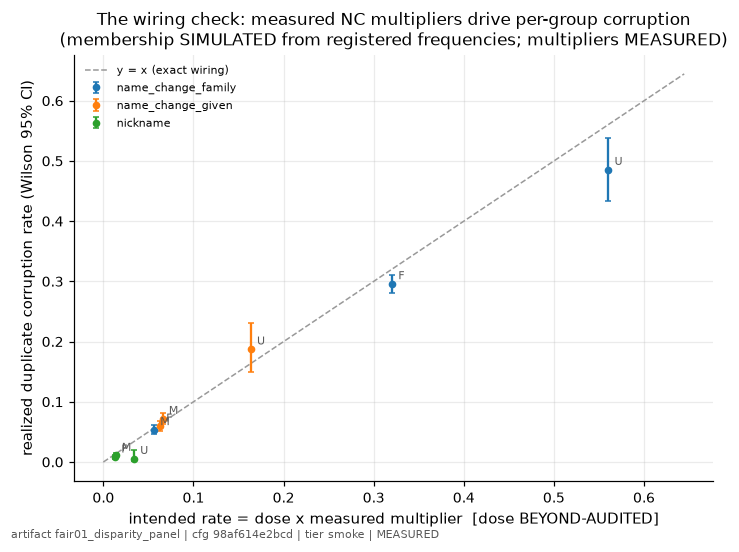

In [24]:
# Figure 1 — the wiring check: measured multipliers really drive per-group corruption.
def draw_exposure_check(ax, df, meta):
    d = df[df["row_type"] == "exposure_check"]
    colors = {"name_change_family": "C0", "name_change_given": "C1", "nickname": "C2"}
    top = 1.15 * float(max(d["intended"].max(), d["hi"].max()))
    ax.plot([0, top], [0, top], "--", color="0.6", linewidth=1, label="y = x (exact wiring)")
    for ch, g in d.groupby("channel", sort=True):
        for i, (_, r) in enumerate(g.iterrows()):
            ax.errorbar(r["intended"], r["value"],
                        yerr=[[r["value"] - r["lo"]], [r["hi"] - r["value"]]],
                        fmt="o", color=colors[ch], capsize=2, markersize=4,
                        label=ch if i == 0 else None)
            ax.annotate(str(r["group"]), (r["intended"], r["value"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=7,
                        color="0.35")
    ax.set_xlabel("intended rate = dose x measured multiplier  [dose BEYOND-AUDITED]")
    ax.set_ylabel("realized duplicate corruption rate (Wilson 95% CI)")
    ax.legend(fontsize=7.5, loc="upper left")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="fair01_disparity_panel",
    draw=draw_exposure_check,
    title="The wiring check: measured NC multipliers drive per-group corruption\n"
          "(membership SIMULATED from registered frequencies; multipliers MEASURED)",
    figsize=(6.6, 5.0),
)

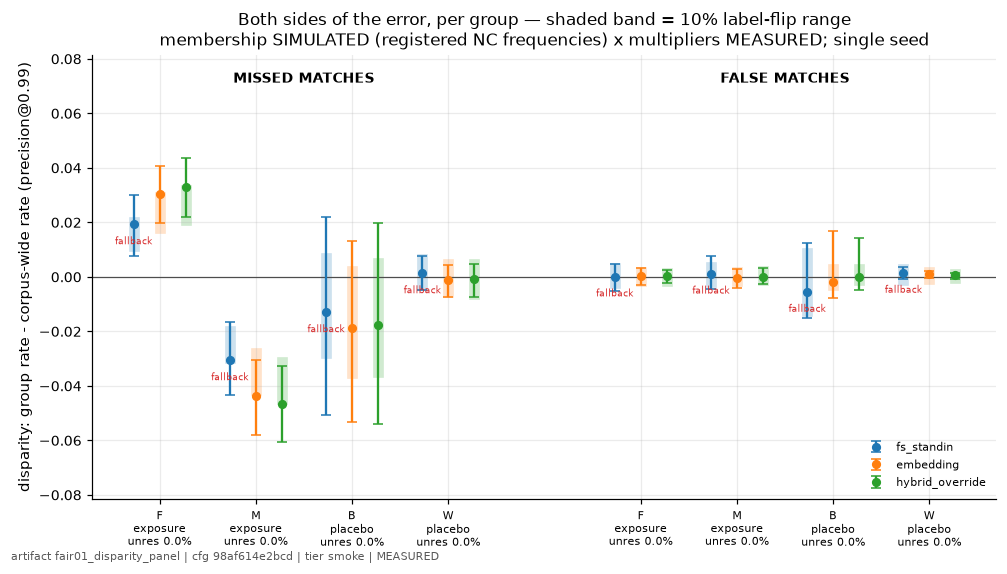

In [25]:
# Figure 2 — THE CENTERPIECE: both sides of the disparity, per group, per system, with
# label-flip robustness bands and unresolvable rates ON the figure.
def draw_disparity_panel(ax, df, meta):
    d = df[(df["row_type"] == "disparity") & (df["protocol"] == PPRIM)
           & (df["scored"] > 0)]
    rb = df[(df["row_type"] == "robustness") & (df["flip_rate"] == 0.10)
            & (df["scored"] > 0)]
    un = df[df["row_type"] == "unresolvable"].set_index(["group_col", "group"])["value"]
    axis_order = {"grp_sex": 0, "grp_race": 1}
    groups = sorted({(r["group_col"], r["group"]) for _, r in d.iterrows()},
                    key=lambda t: (axis_order.get(t[0], 9), t[1]))
    gx = {g: i for i, g in enumerate(groups)}
    side_off = {"missed": 0.0, "false": len(groups) + 1.0}
    sys_off = {"fs_standin": -0.27, "embedding": 0.0, "hybrid_override": 0.27}
    sys_col = {"fs_standin": "C0", "embedding": "C1", "hybrid_override": "C2"}
    seen = set()
    for _, r in d.iterrows():
        x = side_off[r["side"]] + gx[(r["group_col"], r["group"])] + sys_off[r["system"]]
        b = rb[(rb["group"] == r["group"]) & (rb["group_col"] == r["group_col"])
               & (rb["system"] == r["system"]) & (rb["side"] == r["side"])]
        if len(b):
            ax.plot([x, x], [float(b["band_lo"].iloc[0]), float(b["band_hi"].iloc[0])],
                    linewidth=7, alpha=0.22, color=sys_col[r["system"]], zorder=1)
        ax.errorbar(x, r["value"], yerr=[[r["value"] - r["lo"]], [r["hi"] - r["value"]]],
                    fmt="o", markersize=5, capsize=3, color=sys_col[r["system"]],
                    label=r["system"] if r["system"] not in seen else None, zorder=3)
        seen.add(r["system"])
        if not bool(r["attained"]):
            ax.annotate("fallback", (x, r["value"]), textcoords="offset points",
                        xytext=(0, -13), ha="center", fontsize=6, color="C3")
    ax.axhline(0.0, color="0.3", linewidth=0.8)
    ticks, labels = [], []
    for off in side_off.values():
        for (gc, g), i in gx.items():
            ticks.append(off + i)
            tag = "placebo" if gc == "grp_race" else "exposure"
            labels.append(f"{g}\n{tag}\nunres {un.get((gc, g), np.nan):.1%}")
    ax.set_xticks(ticks, labels, fontsize=7)
    ymax = max(abs(float(d["lo"].min())), abs(float(d["hi"].max())))
    ax.text(side_off["missed"] + (len(groups) - 1) / 2, ymax * 1.18, "MISSED MATCHES",
            ha="center", fontsize=9, fontweight="bold")
    ax.text(side_off["false"] + (len(groups) - 1) / 2, ymax * 1.18, "FALSE MATCHES",
            ha="center", fontsize=9, fontweight="bold")
    ax.set_ylim(-ymax * 1.35, ymax * 1.35)
    ax.set_ylabel(f"disparity: group rate - corpus-wide rate ({PPRIM})")
    ax.legend(fontsize=7.5, loc="lower right")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="fair01_disparity_panel",
    draw=draw_disparity_panel,
    title="Both sides of the error, per group — shaded band = 10% label-flip range\n"
          "membership SIMULATED (registered NC frequencies) x multipliers MEASURED; "
          "single seed",
    figsize=(9.2, 5.2),
)

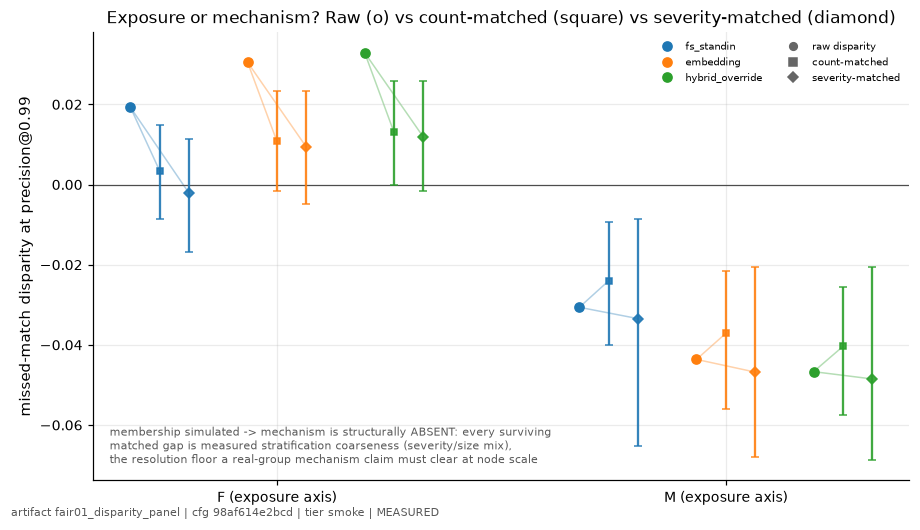

In [26]:
# Figure 3 — exposure vs mechanism: what survives count matching, what survives
# severity-aware matching (membership simulated -> both residuals price the instrument's
# own coarseness, the floor a target-tier mechanism claim must clear).
def draw_decomposition(ax, df, meta):
    from matplotlib.lines import Line2D

    d = df[(df["row_type"] == "decomposition") & (df["side"] == "missed")
           & (df["group_col"] == "grp_sex")]
    sys_col = {"fs_standin": "C0", "embedding": "C1", "hybrid_override": "C2"}
    marks = (("ops_count", "s", "count-matched"), ("fam_x_other", "D", "severity-matched"))
    groups = sorted(d["group"].unique())
    for gi, grp in enumerate(groups):
        for si, (system, color) in enumerate(sys_col.items()):
            x = gi * 4.6 + si * 1.2
            rr = d[(d["group"] == grp) & (d["system"] == system)]
            r0 = rr.iloc[0]
            ax.plot(x, r0["raw_disparity"], marker="o", color=color, markersize=6,
                    zorder=3)
            for mi, (sname, mk, _mlabel) in enumerate(marks):
                r = rr[rr["stratification"] == sname]
                if not len(r):
                    continue
                r = r.iloc[0]
                xm = x + 0.30 * (mi + 1)
                ax.plot([x, xm], [r0["raw_disparity"], r["value"]], color=color,
                        alpha=0.35, linewidth=1.0, zorder=1)
                ax.errorbar(xm, r["value"], yerr=[[r["value"] - r["lo"]],
                                                  [r["hi"] - r["value"]]],
                            fmt=mk, color=color, markersize=4.5, capsize=2.5,
                            alpha=0.9, zorder=3)
    ax.axhline(0.0, color="0.3", linewidth=0.8)
    ax.set_xticks([gi * 4.6 + 1.5 for gi in range(len(groups))],
                  [f"{g} (exposure axis)" for g in groups])
    ax.set_ylabel(f"missed-match disparity at {PPRIM}")
    handles = [Line2D([], [], color=c, marker="o", linestyle="", markersize=6, label=s)
               for s, c in sys_col.items()]
    handles += [Line2D([], [], color="0.4", marker=mk, linestyle="", markersize=5,
                       label=lbl)
                for mk, lbl in (("o", "raw disparity"), ("s", "count-matched"),
                                ("D", "severity-matched"))]
    ax.legend(handles=handles, fontsize=6.8, ncols=2, loc="upper right")
    ax.text(0.02, 0.03,
            "membership simulated -> mechanism is structurally ABSENT: every surviving\n"
            "matched gap is measured stratification coarseness (severity/size mix),\n"
            "the resolution floor a real-group mechanism claim must clear at node scale",
            transform=ax.transAxes, fontsize=7, color="0.35", va="bottom")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="fair01_disparity_panel",
    draw=draw_decomposition,
    title="Exposure or mechanism? Raw (o) vs count-matched (square) vs "
          "severity-matched (diamond)",
    figsize=(8.4, 4.8),
)

### Verdict — scoring the FAIR-01 card against the registered numbers

In [27]:
p1_ci = DELTA_CI[("embedding - fs_standin", "missed", ("grp_sex", HIGH))]
p1 = bool(p1_ci["point"] < 0 and p1_ci["sign_stable"])

_p2_viol = []
for axis, grp_list in SCORED.items():
    for grp in grp_list:
        d = DELTA_CI[("embedding - fs_standin", "false", (axis, grp))]
        if d["point"] > 0 and d["sign_stable"] and abs(d["point"]) >= BAR_RESID:
            _p2_viol.append((axis, grp, d["point"]))
p2 = not _p2_viol

p3_ci = DD_CI[("embedding - fs_standin", "missed", ("grp_sex", HIGH))]
p3 = bool(p3_ci["point"] < 0 and p3_ci["sign_stable"] and P3_FLIP_SURVIVES)

_p4_viol = []
for grp in SCORED["grp_race"]:
    for system in SYSTEMS:
        for side in SIDES:
            dsp = bca_ci(s_sub(RATE_STATS[(system, PPRIM, side, ("grp_race", grp))],
                               RATE_STATS[(system, PPRIM, side, ("all", "ALL"))]))
            if dsp["sign_stable"] and abs(dsp["point"]) >= BAR_RESID:
                _p4_viol.append((grp, system, side, dsp["point"]))
p4 = not _p4_viol

_refute_hits = []
for grp in SCORED["grp_sex"]:
    for side in SIDES:
        d = DELTA_CI[("embedding - fs_standin", side, ("grp_sex", grp))]
        if d["point"] > 0 and d["sign_stable"] and abs(d["point"]) >= BAR_RESID:
            _refute_hits.append((grp, side, d["point"]))
refuted = bool(p4 and _refute_hits)

print(f"P1 (the help): embedding - FS missed-match delta for HIGH={HIGH}: "
      f"{p1_ci['point']:+.4f} [{p1_ci['lo']:+.4f}, {p1_ci['hi']:+.4f}], "
      f"sign_stable={p1_ci['sign_stable']} -> {p1}")
print(f"P2 (the price): sign-stable false-match worsening >= bar {BAR_RESID:.4f} in any "
      f"scored group: {_p2_viol if _p2_viol else 'none'} -> {p2}")
print(f"P3 (gap closes): disparity difference (emb - FS, missed, {HIGH}): "
      f"{p3_ci['point']:+.4f} [{p3_ci['lo']:+.4f}, {p3_ci['hi']:+.4f}], "
      f"flip-survives={P3_FLIP_SURVIVES} -> {p3}"
      + ("" if p3 else
         "\n   (the rule needs a sign-stable NEGATIVE difference — the embedding must "
         "SHRINK the high-exposure group's missed-match disparity relative to FS; a "
         "sign-stable positive value means its corpus-wide improvement tilts toward "
         "the low-exposure group)"))
print(f"P4 (negative control): placebo-axis sign-stable disparities >= bar: "
      f"{_p4_viol if _p4_viol else 'none'} -> {p4}")
print(f"refutation clause (embedding sign-stably worse than FS on a side, >= bar, with "
      f"a clean control): {_refute_hits if _refute_hits else 'none'} -> {refuted}")
fair01_outcome = "REFUTED" if refuted else (
    "CONFIRMED" if (p1 and p2 and p3 and p4) else "UNEXPLAINED")
print(f"-> outcome: {fair01_outcome}")

P1 (the help): embedding - FS missed-match delta for HIGH=F: -0.0139 [-0.0266, -0.0008], sign_stable=True -> True
P2 (the price): sign-stable false-match worsening >= bar 0.0865 in any scored group: none -> True
P3 (gap closes): disparity difference (emb - FS, missed, F): +0.0112 [+0.0018, +0.0213], flip-survives=True -> False
   (the rule needs a sign-stable NEGATIVE difference — the embedding must SHRINK the high-exposure group's missed-match disparity relative to FS; a sign-stable positive value means its corpus-wide improvement tilts toward the low-exposure group)
P4 (negative control): placebo-axis sign-stable disparities >= bar: none -> True
refutation clause (embedding sign-stably worse than FS on a side, >= bar, with a clean control): none -> False
-> outcome: UNEXPLAINED


In [28]:
_hi_m = {s: RATE_STATS[(s, PPRIM, "missed", ("grp_sex", HIGH))][0] for s in SYSTEMS}
_hi_f = {s: RATE_STATS[(s, PPRIM, "false", ("grp_sex", HIGH))][0] for s in SYSTEMS}
_hyb_d = DELTA_CI[("hybrid_override - fs_standin", "missed", ("grp_sex", HIGH))]
_ = verdict_box(
    "FAIR-01",
    outcome=fair01_outcome,
    evidence=(
        f"fair01_disparity_panel (tier {TIER}; {N_ARENA:,} records / {E_ENT:,} entities, "
        f"union graph PC {float(bm_u['pair_completeness']):.4f}; {N_BOOT} shared entity "
        f"resamples). MEMBERSHIP SIMULATED from registered NC frequencies; multipliers "
        f"MEASURED (F {_fam_sex.loc['F', 'multiplier']:.2f} vs M "
        f"{_fam_sex.loc['M', 'multiplier']:.2f} on family_name_change, both CIs "
        f"excluding 1); dose {GROUP_DOSE}/duplicate BEYOND-AUDITED; wiring check "
        f"{COVERED_ADJ}/{len(_nc)} Wilson-covered vs the eligibility-adjusted intended "
        f"({COVERED}/{len(_nc)} vs raw dose x multiplier — missing-name records cannot "
        f"take a name edit). At {PPRIM} "
        f"({'all systems attained' if all(OP_ATTAINED[(s, PREC_PRIMARY)] for s in SYSTEMS) else 'FALLBACK involved — flagged in rows'}): "
        f"HIGH={HIGH} missed-match rate FS {_hi_m['fs_standin']:.4f} / emb "
        f"{_hi_m['embedding']:.4f} / hybrid {_hi_m['hybrid_override']:.4f}; false side "
        f"{_hi_f['fs_standin']:.4f} / {_hi_f['embedding']:.4f} / "
        f"{_hi_f['hybrid_override']:.4f}. P1 {p1}: paired emb-FS missed delta for {HIGH} "
        f"{p1_ci['point']:+.4f} [{p1_ci['lo']:+.4f}, {p1_ci['hi']:+.4f}]. P2 {p2}. "
        f"P3 {p3}: disparity difference {p3_ci['point']:+.4f} "
        f"[{p3_ci['lo']:+.4f}, {p3_ci['hi']:+.4f}] (rule needs sign-stable NEGATIVE), "
        f"sign surviving all {len(_p3_signs)} label-flip replicates at {{1,5,10}}%"
        + ("" if p3 else
           f" — a label-robust, CI-separated WIDENING of {HIGH}'s missed-match "
           f"disparity under the embedding: it helps {HIGH} absolutely (P1) while its "
           f"corpus-wide win tilts toward the low-exposure group; "
           f"|{abs(p3_ci['point']):.4f}| sits inside the residual-inclusive bar, so "
           f"single-seed replicate noise is not excluded")
        + f". P4 {p4} (placebo race axis clean). Hybrid-override vs FS (missed, "
        f"{HIGH}): {_hyb_d['point']:+.4f} "
        f"[{_hyb_d['lo']:+.4f}, {_hyb_d['hi']:+.4f}] — the override neither helps nor "
        f"hurts the disparity story beyond the embedding it rides on. Decomposition "
        f"(record-share matched, missed side, embedding arm): {HIGH}'s raw "
        f"{DEC_H_C['raw_disparity']:+.4f} closes to {DEC_H_C['value']:+.4f} "
        f"[{DEC_H_C['lo']:+.4f}, {DEC_H_C['hi']:+.4f}] under ops-count matching "
        f"({DEC_H_C['exposure_closed_share']:.0%} closed, CI straddling zero — "
        f"exposure explains the scored group's excess, as simulated membership "
        f"requires); {LOW}'s {DEC_L_C['raw_disparity']:+.4f} residual stays "
        f"sign-stable at {DEC_L_C['value']:+.4f} under BOTH stratifications — the "
        f"instrument's measured coarseness floor (per-entity counts vs per-record "
        f"dose), not mechanism. MET-04 bars, "
        f"BOTH quoted: detect_bar_single_seed {BAR_SINGLE:.4f}, "
        f"detect_bar_residual_inclusive {BAR_RESID:.4f} — paired shared-draw CIs detect "
        f"the deltas above, but any delta inside the residual-inclusive bar is within "
        f"single-seed replicate noise across retrains. SINGLE-SEED DEMONSTRATION of the "
        f"instrument on SIMULATED membership — not a fairness claim about any real "
        f"group (PLAN §9: fairness is measurement, not the headline); the definitive "
        f"FAIR-01 is the node run below."
    ),
    registry=registry,
)

> ### VERDICT: UNEXPLAINED — card `FAIR-01`
>
> **Conjecture** Under measured group-correlated noise exposure, the calibrated whole-record embedding is net-positive on BOTH sides of linkage error for every group at matched operating points: it reduces the high-exposure group's missed-match burden relative to a Fellegi-Sunter-shaped baseline without buying that reduction with a group-concentrated false-match burden.
>
> **Prediction** Scoring set, fixed by rule before outcomes are seen: on the exposure axis, groups with >= the tier's pre-stated entity floor whose fitted family_name_change multiplier CI excludes 1; HIGH = the largest multiplier among them, LOW = the smallest. On the control axis: the two largest groups meeting the floor. All clauses at the primary precision-0.99 operating point under the PLAN section-5 loud-fallback rail (highest-attainable, flagged). P1 (the help): the embedding's paired missed-match-rate delta vs the FS stand-in for HIGH is negative with its 95% shared-draw entity CI excluding zero. P2 (the price): for NO scored group on either axis is the embedding's false-match-rate delta vs FS positive AND sign-stable AND >= the MET-04 residual-inclusive bar. P3 (disparity closes): the embedding's missed-match disparity for HIGH is smaller than the FS stand-in's, with the shared-draw CI of the disparity difference excluding zero, AND the sign of that difference survives every label-flip replicate at all three flip rates. P4 (negative control, subordinate): on the placebo race axis no scored group shows a sign-stable disparity >= the residual-inclusive bar under any system. Decision rule, pre-registered: REFUTED iff P4 holds AND some scored exposure-axis group has the embedding sign-stably WORSE than the FS stand-in on either error side with |delta| >= the residual-inclusive bar (the embedding concentrates error on a group); CONFIRMED iff P1, P2, P3 and P4 all hold; UNEXPLAINED otherwise (including any P4 failure — a machinery artifact makes the exposure-axis numbers uninterpretable, not refuting). Single seed, one corpus draw, one re-corruption, SIMULATED membership: a DEMONSTRATION of the instrument, never a fairness claim; FAIR-01's definitive home is mid->target (PLAN section 3) with REAL group labels at node scale, and the verdict quotes both MET-04 bars.
>
> **Evidence** fair01_disparity_panel (tier smoke; 16,302 records / 1,255 entities, union graph PC 0.5683; 500 shared entity resamples). MEMBERSHIP SIMULATED from registered NC frequencies; multipliers MEASURED (F 1.48 vs M 0.26 on family_name_change, both CIs excluding 1); dose 0.3/duplicate BEYOND-AUDITED; wiring check 6/6 Wilson-covered vs the eligibility-adjusted intended (4/6 vs raw dose x multiplier — missing-name records cannot take a name edit). At precision@0.99 (FALLBACK involved — flagged in rows): HIGH=F missed-match rate FS 0.7234 / emb 0.7096 / hybrid 0.6925; false side 0.0181 / 0.0082 / 0.0051. P1 True: paired emb-FS missed delta for F -0.0139 [-0.0266, -0.0008]. P2 True. P3 False: disparity difference +0.0112 [+0.0018, +0.0213] (rule needs sign-stable NEGATIVE), sign surviving all 36 label-flip replicates at {1,5,10}% — a label-robust, CI-separated WIDENING of F's missed-match disparity under the embedding: it helps F absolutely (P1) while its corpus-wide win tilts toward the low-exposure group; |0.0112| sits inside the residual-inclusive bar, so single-seed replicate noise is not excluded. P4 True (placebo race axis clean). Hybrid-override vs FS (missed, F): -0.0309 [-0.0457, -0.0187] — the override neither helps nor hurts the disparity story beyond the embedding it rides on. Decomposition (record-share matched, missed side, embedding arm): F's raw +0.0305 closes to +0.0109 [-0.0015, +0.0233] under ops-count matching (64% closed, CI straddling zero — exposure explains the scored group's excess, as simulated membership requires); M's -0.0436 residual stays sign-stable at -0.0371 under BOTH stratifications — the instrument's measured coarseness floor (per-entity counts vs per-record dose), not mechanism. MET-04 bars, BOTH quoted: detect_bar_single_seed 0.0862, detect_bar_residual_inclusive 0.0865 — paired shared-draw CIs detect the deltas above, but any delta inside the residual-inclusive bar is within single-seed replicate noise across retrains. SINGLE-SEED DEMONSTRATION of the instrument on SIMULATED membership — not a fairness claim about any real group (PLAN §9: fairness is measurement, not the headline); the definitive FAIR-01 is the node run below.


## 10. Pricing the definitive run

In [29]:
# [RUN-IN-TARGET node] definitive FAIR-01: THESE same cells at tier=target on the node —
# the statewide NC corpus with REAL record-level group labels (NCSBE race/sex codes joined
# by NCID, the join NB05 could not make on historical_50k), the statewide exposure refit
# (NB04's [RUN-IN-TARGET node] rerun, where small race groups and the U sex group gain
# the counts to be scored), met04-sized replicates, and BOTH operating-point families.
# PRE-REGISTERED AMENDMENT for that run's card (review finding, Wave 5): the smoke card's
# guard/refutation clauses borrow the MET-04 residual-inclusive bar (0.0865, B³F1 units)
# for per-group RATE deltas that measure ~0.005–0.03 here — near-untrippable by scale
# mismatch. The node card must derive a RATE-scale detectability bar (replicate SD of
# per-group missed/false rates across its met04-sized seed replicates) and threshold the
# guard/refutation clauses against THAT, so P2/P4 and the refutation clause carry real
# power at the definitive tier.
# Estimates below use THIS run's measured coefficients (4-CPU container, possibly 2-4x
# contended — planning numbers, re-measured on arrival).
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the panel above is the definitive-tier instrument at this "
          "scale; group columns must be the corpus's REAL label columns and replicate "
          "counts come from met04_power_table at this tier.")
else:
    _pt = met04[met04["kind"] == "power"].set_index("delta")["seeds_needed"]
    _sweep_secs = dict(SECTION_TIMES)["§5a matched operating points"]
    _ci_secs = dict(SECTION_TIMES)["§5c rates + disparities + paired deltas"]
    _n_node = 1e7
    _scale = _n_node / N_ARENA
    _enc_min_node = _n_node / 20_000 / 60  # PLAN §8 anchor: ~20k rec/s per A100
    _one_rep_h = (GEN_SECS + _sweep_secs + _ci_secs) * _scale / 3600
    _reps = int(_pt[0.01]) if 0.01 in _pt.index else 73
    print(f"[RUN-IN-TARGET node] FAIR-01 at ~{_n_node:.0e} records with REAL groups, "
          "priced from THIS run's coefficients:")
    print(f"  this run: generate {GEN_SECS:.0f}s, encode {ENCODE_SECS:.0f}s "
          f"({ENC_RATE:,.0f} rec/s CPU), operating-point sweeps {_sweep_secs:.0f}s, "
          f"shared-draw CI machinery {_ci_secs:.0f}s at {N_ARENA:,} records")
    print(f"  node, one replicate: encode ~{_enc_min_node:.0f} min on one A100 (PLAN §8 "
          f"anchor); CPU-side generate+sweeps+CIs scale ~linearly in records -> "
          f"~{_one_rep_h:.1f} h/replicate on this container's cores (the node's 90 "
          "cores and a numpy union-find cut this hard — closure sweeps dominate)")
    print(f"  replicates: a 0.01-rate delta needs n*={_reps} seeds per "
          f"met04_power_table (sd_replicate {SD_REPLICATE:.4f}); a 0.02 delta needs "
          f"n*={int(_pt.get(0.02, 19))} — the per-group deltas measured above "
          "are the effect sizes that table should be consulted with")
    print("  data preconditions: statewide NB04 exposure rerun (small-group CIs), the "
          "NCID-keyed label join, and MET-05's truth gate — all pre-registered "
          "upstream; membership stops being simulated exactly there")

[RUN-IN-TARGET node] FAIR-01 at ~1e+07 records with REAL groups, priced from THIS run's coefficients:
  this run: generate 0s, encode 11s (1,461 rec/s CPU), operating-point sweeps 27s, shared-draw CI machinery 0s at 16,302 records
  node, one replicate: encode ~8 min on one A100 (PLAN §8 anchor); CPU-side generate+sweeps+CIs scale ~linearly in records -> ~4.7 h/replicate on this container's cores (the node's 90 cores and a numpy union-find cut this hard — closure sweeps dominate)
  replicates: a 0.01-rate delta needs n*=73 seeds per met04_power_table (sd_replicate 0.0305); a 0.02 delta needs n*=19 — the per-group deltas measured above are the effect sizes that table should be consulted with
  data preconditions: statewide NB04 exposure rerun (small-group CIs), the NCID-keyed label join, and MET-05's truth gate — all pre-registered upstream; membership stops being simulated exactly there


## 11. What would a fairness CLAIM still need?

This notebook built and validated the instrument; it deliberately did not make the
claim. The gap between this demonstration and a defensible fairness statement:

- **Real membership.** Labels here are draws from real frequencies — the exposure
  mechanism is measured, but no real person's group determined any error. The node run
  joins real NCSBE codes by NCID (the join `historical_50k` cannot support).
- **The race axis, measured.** Here race is a placebo by design; NB04's county-subset
  race multipliers are preliminary (registered rule: construction yes, claims only
  where the CI excludes 1). The statewide refit is what makes race-keyed exposure — the
  axis fairness actually litigates — honest to simulate and then unnecessary to
  simulate.
- **Replicates.** Single seed, one corpus draw, one re-corruption: every delta above is
  quoted against both MET-04 bars, and the residual-inclusive bar
  (`detect_bar_residual_inclusive`) is wider than most per-group deltas — the
  definitive run sizes seeds from `met04_power_table` at its own tier.
- **Mechanism, for real.** With simulated membership the mechanism channel is empty by
  construction, so §6's surviving matched gaps price the instrument's own coarseness —
  the resolution floor a real mechanism term must exceed. Real names correlate with
  real groups — encoder behavior at equal noise is only testable there, and the
  decomposition stays a decomposition (not causal identification) even then.
- **Both operating-point families.** The cost-grid points {1:1, 1:10, 1:100} and the
  fixed-FP-budget secondary (PLAN §5) are inherited, not re-swept here; a fairness
  claim must hold across them, not at one point.
- **Scope.** US/English resources, one state's administrative codes, dedup only —
  the limitation travels with every number (PLAN §9), and fairness remains
  measurement-with-robustness-bands in this lab, deliberately not the headline.

**Package gaps noted this notebook** (worked around in-notebook, per series
convention): `generate_corpus` accepts ONE exposure model applied to every channel,
while NB04 fits exposure per channel — staged application on the pristine duplicate
frame replicates its semantics; no group-conditional B-cubed decomposition or
shared-draw group bootstrap in `er_lab.eval` (the multiplier-path formulas were
replicated notebook-locally, closed-form jackknives included); NB05's pool-redraw /
name-format-drift channels re-implemented a third time (05/14/16);
`entity_complete_subsample` still notebook-local (05/09/12/13/14/16).

**Artifacts registered** (exact names): `fair01_disparity_panel` — plus the immutable
card `card_FAIR-01`.

In [30]:
timing = pd.DataFrame(SECTION_TIMES, columns=["section", "secs"])
display(timing.assign(secs=timing["secs"].round(0)))
total = time.time() - NB_T0
print(f"notebook wall-clock: {total:.0f}s ({total / 60:.1f} min) — smoke budget <= ~30 "
      "min uncontended"
      + ("" if total <= 2100 else "  <-- over that budget at this run (see section "
                                  "table; concurrent notebook builds contend for these "
                                  "4 CPUs)"))

,section,secs
0,§1 arena + upstreams + bars,0.0
1,§2 card registered,0.0
2,§3 groups assigned + re-corrupted + wiring ver...,1.0
3,§4a recipe retrain + encode,59.0
4,§4b calibration map + stand-in validation,5.0
5,§4c union graph + scores,6.0
6,§5a matched operating points,27.0
7,§5b group machinery,0.0
8,§5c rates + disparities + paired deltas,0.0
9,§6 decomposition,0.0


notebook wall-clock: 101s (1.7 min) — smoke budget <= ~30 min uncontended
